# The Exclusion Ratchet — analysis

Derivation record for *The Exclusion Ratchet: False-Positive Suppression Accumulates and
Persists in Detection Rule Repositories*.

These cells were developed inside the `structural.ipynb` notebook released by Long and
Evans (2026), because that notebook constructs the aligned revision steps this study
reclassifies. They are reproduced here so that this repository contains the derivation
of its own results. Cells 0–21 of the upstream notebook are the authors' work and are
**not** reproduced; nothing here modifies their analysis.

**Prerequisites** — see `data/README.md`:

* the Long and Evans checkout as a sibling directory, with `data_prep/` populated
* the SigmaHQ repository cloned as a sibling, with full history
* their `structural.ipynb` run once, so that `.cache/struct_ops_sigma.pkl` exists

**Definitions are not restated here.** `src/detector.py` and `src/forgeability.py` hold
the canonical implementations and are imported below. Divergence between cell-local
copies of a definition and the module was the direct cause of corrections 3 and 4;
do not paste a definition into a cell.

Snapshot: 10 April 2026.


In [1]:
# ── Bootstrap ────────────────────────────────────────────────────────────────
# Reaches into the upstream checkout for prepared data and alignment helpers.
# Nothing in the upstream repository is written to.
import json
import pickle
import sys
from collections import defaultdict
from pathlib import Path

import pandas as pd

REPO      = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
UPSTREAM  = REPO.parent / 'Evolution-of-Log-Based-Detection-Rules'
ALIGN_SRC = UPSTREAM / 'data_prep/align_src'
BUILD     = UPSTREAM / 'data_prep/build_data'
IR_DATA   = UPSTREAM / 'data_prep/ir_data'
CACHE     = UPSTREAM / 'analysis/scripts/.cache/struct_ops_sigma.pkl'
SIGMA     = REPO.parent / 'sigma'
RESULTS   = REPO / 'results'

sys.path.insert(0, str(ALIGN_SRC))        # their alignment helpers
sys.path.insert(0, str(REPO / 'src'))     # our frozen definitions

from pgir_align import build_canonical_tree, tree_signature          # noqa: E402
from structural_ops_helpers import load_pgir_index_selective         # noqa: E402,F401

from detector import *                                              # noqa: E402,F401,F403
from forgeability import (                                          # noqa: E402,F401
    report, classify, anchor, is_path_field, base_field,
)

SNAPSHOT = pd.to_datetime('2026-04-10', utc=True)


def load_pgir_for_lineages(repo: str, lineage_ids: set):
    """PGIR records for the requested lineages, ordered by version.

    Our own loader. The upstream helper of the same name lives in a notebook cell
    rather than in an importable module, and we do not copy their code.
    """
    out = defaultdict(list)
    with (IR_DATA / f'pgir_{repo}_nonempty.jsonl').open(encoding='utf-8') as fh:
        for line in fh:
            if not line.strip():
                continue
            rec = json.loads(line)
            if rec['lineage_id'] in lineage_ids:
                out[rec['lineage_id']].append(rec)
    for lid in out:
        out[lid].sort(key=lambda r: r['version_index'])
    return out


# Aligned revision steps, from the cache their notebook writes.
with CACHE.open('rb') as fh:
    res = pickle.load(fh)['results']

lineage_ids = {s['lineage_id'] for s in res}

# (lineage, version) -> commit date, for every version we will need
date_of = {}
with (BUILD / 'rule_versions_sigma.jsonl').open(encoding='utf-8') as fh:
    for line in fh:
        r = json.loads(line)
        date_of[(r['lineage_id'], r['version_index'])] = pd.to_datetime(
            r['commit_date'], utc=True)

print(f'revision steps loaded : {len(res):,}')
print(f'lineages              : {len(lineage_ids):,}')
print(f'versions dated        : {len(date_of):,}')
print(f'upstream checkout     : {UPSTREAM}')
print(f'results written to    : {RESULTS}')


revision steps loaded : 8,234
lineages              : 2,355
versions dated        : 43,684
upstream checkout     : C:\Users\sudar\Desktop\Preparation\research\Evolution-of-Log-Based-Detection-Rules
results written to    : C:\Users\sudar\Desktop\Preparation\research\coverage-decay\results


In [2]:
SNAPSHOT = pd.to_datetime('2026-04-10', utc=True)

def find_change_episodes(version_records, snapshot=SNAPSHOT):
    sigs  = [tree_signature(build_canonical_tree(r)) for r in version_records]
    dates = [pd.to_datetime(r['commit_date'], utc=True) for r in version_records]
    out, n = [], len(version_records)
    for i in range(n - 1):
        if sigs[i] == sigs[i + 1]:
            continue
        restore_at = next((j for j in range(i + 2, n) if sigs[j] == sigs[i]), None)
        if restore_at is not None:
            dur, cens = (dates[restore_at] - dates[i+1]).total_seconds()/3600.0, False
        else:
            dur, cens = (snapshot - dates[i+1]).total_seconds()/3600.0, True
        out.append({'lineage_id': version_records[i]['lineage_id'],
                    'changed_at': dates[i+1], 'duration_h': dur, 'censored': cens})
    return out

print("ready")

ready


In [3]:
pgir_all = load_pgir_for_lineages('sigma', lineage_ids)
print(f"lineages loaded: {len(pgir_all)}")

eps = []
for lid, versions in pgir_all.items():
    if len(versions) >= 2:
        eps.extend(find_change_episodes(versions))

df = pd.DataFrame(eps)
print(f"total change episodes : {len(df)}")
print(f"restored              : {(~df.censored).sum()}")
print(f"NEVER restored        : {df.censored.sum()}  ({100*df.censored.mean():.1f}%)")
print(f"median hours, restored: {df.loc[~df.censored,'duration_h'].median():.1f}")
print(f"median age, censored  : {df.loc[df.censored,'duration_h'].median():.1f}")

lineages loaded: 2355
total change episodes : 8234
restored              : 544
NEVER restored        : 7690  (93.4%)
median hours, restored: 150.2
median age, censored  : 32325.1


In [4]:
print(df.groupby('lineage_id').size().describe())
print(f"\nepisodes per lineage: {len(df)/df.lineage_id.nunique():.1f}")

count    2355.000000
mean        3.496391
std         4.108383
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        42.000000
dtype: float64

episodes per lineage: 3.5


In [5]:
import pickle
so = pickle.load(open(CACHE, 'rb'))
print(type(so))
k = list(so)[:2] if hasattr(so,'__iter__') else None
print(k)
print(so[k[0]] if k else so)

<class 'dict'>
['helper_fingerprint', 'results']
16dc2aa5fe2994dd4f98ad063b3f34b7e63a8a900a02e5e76b8a74c4622db2eb


In [6]:
res = so['results']
print(type(res), len(res))
print(res[0].keys())
print()
print(res[0])

<class 'list'> 8234
dict_keys(['ops', 'evidence', 'align_summary', 'tree_a', 'tree_b', 'sig_a', 'sig_b', 'lineage_id', 'version_a', 'version_b'])

{'ops': {'OR_ADD': False, 'OR_REMOVE': False, 'AND_ADD': False, 'AND_REMOVE': True, 'PRED_SCOPE_REASSIGN': False, 'PRED_CONTEXT_RELABEL': False, 'PRED_UPDATE': False, 'BRANCH_ADD': False, 'BRANCH_REMOVE': False, 'BRANCH_OR_ADD': False, 'BRANCH_AND_ADD': False, 'BRANCH_OR_REMOVE': False, 'BRANCH_AND_REMOVE': False}, 'evidence': {'n_pred_added_under_existing_or': 0, 'n_pred_added_under_existing_and': 0, 'n_pred_added_at_root': 0, 'n_pred_added_under_new_scope': 0, 'n_pred_removed_from_existing_or': 0, 'n_pred_removed_from_existing_and': 1, 'n_pred_removed_at_root': 0, 'n_pred_removed_from_old_scope': 0, 'n_new_or_ops': 0, 'n_new_and_ops': 0, 'n_new_not_ops': 0, 'n_new_or_with_preds': 0, 'n_new_and_with_preds': 0, 'n_removed_or_ops': 0, 'n_removed_and_ops': 0, 'n_removed_not_ops': 0, 'n_removed_or_with_preds': 0, 'n_removed_and_with_preds': 0, 

In [7]:
ops_df = pd.DataFrame([{
    'lineage_id': r['lineage_id'],
    'version_a': r['version_a'], 'version_b': r['version_b'],
    'and_add':    r['evidence']['n_pred_added_under_existing_and'],
    'or_remove':  r['evidence']['n_pred_removed_from_existing_or'],
    'and_remove': r['evidence']['n_pred_removed_from_existing_and'],
    'or_add':     r['evidence']['n_pred_added_under_existing_or'],
    'n_not_a':    r['tree_a']['n_not'],
    'n_not_b':    r['tree_b']['n_not'],
} for r in res])

ops_df['narrowing']  = ops_df.and_add    + ops_df.or_remove
ops_df['broadening'] = ops_df.and_remove + ops_df.or_add

def direction(r):
    if r.narrowing > 0 and r.broadening == 0: return 'narrow'
    if r.broadening > 0 and r.narrowing == 0: return 'broaden'
    if r.narrowing > 0 and r.broadening > 0:  return 'mixed'
    return 'other'

ops_df['direction'] = ops_df.apply(direction, axis=1)
print(ops_df.direction.value_counts())
print()
print("steps that change NOT count:", (ops_df.n_not_a != ops_df.n_not_b).sum())

direction
other      5177
mixed      1388
broaden     970
narrow      699
Name: count, dtype: int64

steps that change NOT count: 742


In [8]:
ev_keys = list(res[0]['evidence'].keys())
op_keys = list(res[0]['ops'].keys())

other_idx = ops_df.index[ops_df.direction == 'other']

ev = pd.DataFrame([res[i]['evidence'] for i in other_idx])
print("evidence fields non-zero among 'other' steps:")
print((ev != 0).sum().sort_values(ascending=False).head(12))

op = pd.DataFrame([res[i]['ops'] for i in other_idx])
print("\nops flags True among 'other' steps:")
print(op.sum().sort_values(ascending=False).head(10))

evidence fields non-zero among 'other' steps:
n_pred_update                    3429
n_pred_value_shift               2923
n_pred_added_under_new_scope     1436
n_new_and_ops                    1285
n_pred_scope_reassign            1220
n_new_or_ops                      901
n_removed_and_ops                 812
n_new_and_with_preds              719
n_pred_removed_from_old_scope     697
n_pred_field_shift                604
n_new_or_with_preds               596
n_new_not_ops                     564
dtype: int64

ops flags True among 'other' steps:
PRED_UPDATE            3429
BRANCH_ADD             1312
PRED_SCOPE_REASSIGN    1220
BRANCH_AND_ADD          719
BRANCH_REMOVE           680
BRANCH_OR_ADD           596
BRANCH_AND_REMOVE       450
BRANCH_OR_REMOVE        234
AND_REMOVE              216
AND_ADD                 176
dtype: int64


In [9]:
import json, re
from collections import Counter, defaultdict

tags = json.load(open(RESULTS / 'lineage_attack_tags.json'))

def root_op(sig):
    m = re.match(r"\(\\?'O:(\w+)", sig)
    return m.group(1) if m else 'other'

def has_neg(r):
    return 'CTX:NEG' in r['sig_a'] or 'CTX:NEG' in r['sig_b']

def direction(r):
    e, o = r['evidence'], r['ops']
    ra = root_op(r['sig_a']); nar = bro = 0
    nar += e['n_pred_added_under_existing_and'] + e['n_pred_removed_from_existing_or']
    bro += e['n_pred_removed_from_existing_and'] + e['n_pred_added_under_existing_or']
    if ra == 'AND':
        nar += e['n_pred_added_at_root'];  bro += e['n_pred_removed_at_root']
    elif ra == 'OR':
        bro += e['n_pred_added_at_root'];  nar += e['n_pred_removed_at_root']
    if o['BRANCH_AND_ADD']:    nar += 1
    if o['BRANCH_OR_REMOVE']:  nar += 1
    if o['BRANCH_AND_REMOVE']: bro += 1
    if o['BRANCH_OR_ADD']:     bro += 1
    nar += e['n_new_not_ops']; bro += e['n_removed_not_ops']
    if nar and not bro: return 'narrow'
    if bro and not nar: return 'broaden'
    return 'mixed' if (nar and bro) else 'unclassified'

res   = so['results']
study = {r['lineage_id'] for r in res}
techs = lambda l: [t for t in tags.get(l, []) if t.split('.')[1:2] and t.split('.')[1].startswith('t')]
cover = Counter(t for l in study for t in techs(l))
singl = {t for t, n in cover.items() if n == 1}

# steps per lineage, ordered
by_lin = defaultdict(list)
for r in res:
    by_lin[r['lineage_id']].append(r)
for v in by_lin.values():
    v.sort(key=lambda x: x['version_a'])

# date lookup
date_of = {}
for lid, recs in pgir_all.items():
    for rec in recs:
        date_of[(lid, rec['version_index'])] = pd.to_datetime(rec['commit_date'], utc=True)

rows = []
for r in res:
    if has_neg(r) or direction(r) != 'narrow':
        continue
    lid = r['lineage_id']
    hits = [t for t in techs(lid) if t in singl]
    if not hits:
        continue
    t0 = date_of.get((lid, r['version_b']))
    if t0 is None:
        continue
    later = [s for s in by_lin[lid] if s['version_a'] >= r['version_b']]
    back  = next((s for s in later if s['sig_b'] == r['sig_a']), None)
    if back:
        t1 = date_of.get((lid, back['version_b']))
        dur, cens = ((t1 - t0).total_seconds()/3600.0, False) if t1 is not None else (None, None)
    else:
        dur, cens = (SNAPSHOT - t0).total_seconds()/3600.0, True
    rows.append({'lineage': lid, 'techniques': ','.join(hits),
                 'narrowed_on': t0.date(), 'duration_h': dur, 'censored': cens})

ev = pd.DataFrame(rows)
print(f"singleton-technique narrowing events: {len(ev)}")
print(f"  never reverted (censored)         : {ev.censored.sum()}")
print(f"  reverted                          : {(~ev.censored).sum()}")
print()
print(ev.sort_values('duration_h', ascending=False).to_string(index=False))

singleton-technique narrowing events: 17
  never reverted (censored)         : 12
  reverted                          : 5

      lineage       techniques narrowed_on   duration_h  censored
lineage_02470 attack.t1090.002  2020-01-30 54278.843889      True
lineage_00284     attack.t1125  2021-07-01 41849.441667      True
lineage_02080 attack.t1499.001  2021-11-17 38514.000833      True
lineage_02083     attack.t1689  2022-05-10 34334.872222      True
lineage_02627     attack.t1525  2022-06-08 33634.208333      True
lineage_01492 attack.t1499.004  2022-10-21 30397.140833      True
lineage_04136 attack.t1547.015  2023-07-24 23775.367778      True
lineage_02035 attack.t1037.005  2024-08-10 14568.340000      True
lineage_00354 attack.t1599.001  2024-11-25 12015.496111      True
lineage_00615 attack.t1134.004  2024-11-25 12015.496111      True
lineage_02073     attack.t1622  2024-11-25 12015.496111      True
lineage_03693 attack.t1134.003  2024-11-25 12015.496111      True
lineage_00361 attac

In [10]:
neg_a = r['sig_a'].count('CTX:NEG')
neg_b = r['sig_b'].count('CTX:NEG')

In [11]:
from collections import Counter, defaultdict

negdelta = lambda r: r['sig_b'].count('CTX:NEG') - r['sig_a'].count('CTX:NEG')

sup = [r for r in res if negdelta(r) > 0]     # exclusion grew  -> suppression
rel = [r for r in res if negdelta(r) < 0]     # exclusion shrank -> relaxation

print(f'total steps                       : {len(res)}')
print(f'  exclusion GREW  (suppression)   : {len(sup)}')
print(f'  exclusion SHRANK (relaxation)   : {len(rel)}')
print(f'  no change in negated predicates : {len(res)-len(sup)-len(rel)}')

study = {r['lineage_id'] for r in res}
techs = lambda l: [t for t in tags.get(l,[]) if t.split('.')[1:2] and t.split('.')[1].startswith('t')]
cover = Counter(t for l in study for t in techs(l))
singl = {t for t,n in cover.items() if n == 1}

hit = defaultdict(list)
for r in sup:
    for t in techs(r['lineage_id']):
        if t in singl:
            hit[t].append(r)

print()
print(f'singleton techniques whose sole rule was SUPPRESSED : {len(hit)}')
print(f'  suppression events on those rules                 : {sum(len(v) for v in hit.values())}')
print()
for t, v in sorted(hit.items(), key=lambda x: -len(x[1]))[:20]:
    print(f'   {t:22} {len(v):2} event(s)   {sorted({r["lineage_id"] for r in v})}')

total steps                       : 8234
  exclusion GREW  (suppression)   : 1204
  exclusion SHRANK (relaxation)   : 287
  no change in negated predicates : 6743

singleton techniques whose sole rule was SUPPRESSED : 17
  suppression events on those rules                 : 49

   attack.t1006           13 event(s)   ['lineage_02910']
   attack.t1036.008        9 event(s)   ['lineage_02755']
   attack.t1001.003        5 event(s)   ['lineage_03451']
   attack.t1134            4 event(s)   ['lineage_03674']
   attack.t1027.002        3 event(s)   ['lineage_00997']
   attack.t1218.013        2 event(s)   ['lineage_03916']
   attack.t1553.003        2 event(s)   ['lineage_04329']
   attack.t1090.002        2 event(s)   ['lineage_02470']
   attack.t1127.001        1 event(s)   ['lineage_01569']
   attack.t1595.002        1 event(s)   ['lineage_03976']
   attack.t1614.001        1 event(s)   ['lineage_02824']
   attack.t1218.002        1 event(s)   ['lineage_02923']
   attack.t1218.009      

In [12]:
from collections import defaultdict
import pandas as pd

if 'by_lin' not in dir():
    by_lin = defaultdict(list)
    for r in res: by_lin[r['lineage_id']].append(r)
    for v in by_lin.values(): v.sort(key=lambda x: x['version_a'])

if 'date_of' not in dir():
    date_of = {(l, rec['version_index']): pd.to_datetime(rec['commit_date'], utc=True)
               for l, recs in pgir_all.items() for rec in recs}

rows = []
for t, evs in hit.items():
    for r in evs:
        lid  = r['lineage_id']
        n_a  = r['sig_a'].count('CTX:NEG')
        t0   = date_of.get((lid, r['version_b']))
        if t0 is None: continue
        later = [s for s in by_lin[lid] if s['version_a'] >= r['version_b']]
        back  = next((s for s in later if s['sig_b'].count('CTX:NEG') <= n_a), None)
        if back:
            t1 = date_of.get((lid, back['version_b']))
            dur, cens = ((t1-t0).total_seconds()/3600, False) if t1 is not None else (None, None)
        else:
            dur, cens = (SNAPSHOT-t0).total_seconds()/3600, True
        rows.append({'technique': t, 'lineage': lid, 'suppressed_on': t0.date(),
                     'days': None if dur is None else round(dur/24, 1), 'censored': cens})

ex = pd.DataFrame(rows)
print(f"suppression events on singleton-covered techniques : {len(ex)}")
print(f"  never removed (censored)                         : {ex.censored.sum()}")
print(f"  removed                                          : {(~ex.censored).sum()}")
print(f"  median days, never removed                       : {ex.loc[ex.censored,'days'].median():.0f}")
print(f"  median days, removed                             : {ex.loc[~ex.censored,'days'].median():.1f}")
print()
print(ex.sort_values('days', ascending=False).head(20).to_string(index=False))

suppression events on singleton-covered techniques : 49
  never removed (censored)                         : 37
  removed                                          : 12
  median days, never removed                       : 1380
  median days, removed                             : 34.0

       technique       lineage suppressed_on   days  censored
attack.t1134.005 lineage_03040    2019-07-17 2459.0      True
    attack.t1010 lineage_00327    2021-04-26 1809.2      True
attack.t1546.010 lineage_01111    2021-11-11 1610.3      True
    attack.t1006 lineage_02910    2021-11-16 1605.1      True
attack.t1027.002 lineage_00997    2021-12-03 1588.2      True
    attack.t1006 lineage_02910    2021-12-04 1587.4      True
attack.t1027.002 lineage_00997    2021-12-05 1586.6      True
    attack.t1006 lineage_02910    2021-12-13 1578.2      True
    attack.t1006 lineage_02910    2022-01-02 1558.6      True
    attack.t1006 lineage_02910    2022-02-07 1522.5      True
    attack.t1006 lineage_02910   

In [13]:
import json, csv
meta = json.load(open(BUILD / 'lineage_metadata_final_sigma.json'))
by_id = {m['lineage_id']: m for m in meta}

rows = []
for _, e in ex.iterrows():
    m = by_id.get(e['lineage'], {})
    subs = [c['subject'] for c in m.get('commits', [])
            if c['date'][:10] == str(e['suppressed_on'])]
    rows.append({
        'technique': e['technique'], 'lineage': e['lineage'],
        'date': e['suppressed_on'], 'days': e['days'], 'censored': e['censored'],
        'rule': (m.get('canonical_name') or '').split('/')[-1],
        'commit_subjects': ' | '.join(subs)[:200],
        'verdict': ''
    })

with open(RESULTS / 'validation_worksheet.csv','w',
          newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0]))
    w.writeheader(); w.writerows(rows)

for r in sorted(rows, key=lambda x: -x['days']):
    print(f"{r['technique']:22} {r['date']} {r['days']:>7.0f}d  {r['rule'][:38]:40} {r['commit_subjects'][:70]}")

attack.t1134.005       2019-07-17    2459d  win_security_susp_add_sid_history.yml    rules/windows/builtin/win_susp_add_sid_history.yml improved | changed 
attack.t1010           2021-04-26    1809d  win_security_scm_database_handle_failu   Update win_scm_database_handle_failure.yml
attack.t1546.010       2021-11-11    1610d  registry_event_new_dll_added_to_appini   filter out where Details is (Empty) | updating modified date and autho
attack.t1006           2021-11-16    1605d  raw_access_thread_susp_disk_access_usi   fix: more false positive fixes
attack.t1027.002       2021-12-03    1588d  image_load_susp_python_image_load.yml    fix: more FPs noticed with Aurora
attack.t1006           2021-12-04    1587d  raw_access_thread_susp_disk_access_usi   fix: FPs noticed with Aurora
attack.t1027.002       2021-12-05    1587d  image_load_susp_python_image_load.yml    fix: FPs noticed with Aurora
attack.t1006           2021-12-13    1578d  raw_access_thread_susp_disk_access_usi   Fix FP
attac

In [14]:
import re
fp = re.compile(r'\bfps?\b|false.positive|filter out', re.I)
for r in rows:
    r['fp_stated'] = bool(fp.search(r['commit_subjects'] or ''))

n = sum(r['fp_stated'] for r in rows)
print(f"events with explicit FP language : {n} / {len(rows)}  ({100*n/len(rows):.0f}%)")
print()
print("NOT explicitly FP — classify these by hand:")
for r in sorted(rows, key=lambda x: -x['days']):
    if not r['fp_stated']:
        print(f"  {r['technique']:20} {r['date']}  {r['days']:>6.0f}d  {r['rule'][:34]:36} {r['commit_subjects'][:70]}")

events with explicit FP language : 36 / 49  (73%)

NOT explicitly FP — classify these by hand:
  attack.t1134.005     2019-07-17    2459d  win_security_susp_add_sid_history.   rules/windows/builtin/win_susp_add_sid_history.yml improved | changed 
  attack.t1010         2021-04-26    1809d  win_security_scm_database_handle_f   Update win_scm_database_handle_failure.yml
  attack.t1006         2022-01-02    1559d  raw_access_thread_susp_disk_access   Update rule
  attack.t1001.003     2022-03-26    1475d  file_event_win_adsi_cache_creation   Filtering of ccm setup executables | OOps... syntax err... early morni
  attack.t1090.002     2022-06-29    1380d  win_security_rdp_reverse_tunnel.ym   fix: technically filter THOR checking for BlueKeep vuln
  attack.t1218.013     2022-09-07    1311d  proc_creation_win_lolbin_mavinject   More updates
  attack.t1001.003     2023-10-23     900d  file_event_win_adsi_cache_creation   Merge PR #4491 from @nasbench - Rule Updates & Fixes
  attack.t1134     

In [15]:
fp = re.compile(r'\bfps?\b|false.positive|filter', re.I)

In [16]:
def deltas(step):
    return (step['sig_b'].count('CTX:POS') - step['sig_a'].count('CTX:POS'),
            step['sig_b'].count('CTX:NEG') - step['sig_a'].count('CTX:NEG'))

def is_suppression(step):
    """Exclusion grew while the positive selection did not."""
    pos, neg = deltas(step)
    return neg > 0 and pos <= 0

In [17]:
from collections import Counter, defaultdict
import pandas as pd

def deltas(s):
    return (s['sig_b'].count('CTX:POS') - s['sig_a'].count('CTX:POS'),
            s['sig_b'].count('CTX:NEG') - s['sig_a'].count('CTX:NEG'))

def is_suppression(s):
    pos, neg = deltas(s); return neg > 0 and pos <= 0

def is_expansion_with_guard(s):
    pos, neg = deltas(s); return neg > 0 and pos > 0

sup   = [s for s in res if is_suppression(s)]
guard = [s for s in res if is_expansion_with_guard(s)]
print(f'suppressions (strict)        : {len(sup)}')
print(f'expansion-with-guard (excl.) : {len(guard)}')

techs = lambda l: [t for t in tags.get(l,[]) if t.split('.')[1:2] and t.split('.')[1].startswith('t')]
study = {s['lineage_id'] for s in res}
cover = Counter(t for l in study for t in techs(l))
singl = {t for t,n in cover.items() if n == 1}

hit = defaultdict(list)
for s in sup:
    for t in techs(s['lineage_id']):
        if t in singl:
            hit[t].append(s)

rows2 = []
for t, evs in hit.items():
    for s in evs:
        lid   = s['lineage_id']
        before = s['sig_a'].count('CTX:NEG')
        t0 = date_of.get((lid, s['version_b']))
        if t0 is None: continue
        after  = [x for x in by_lin[lid] if x['version_a'] >= s['version_b']]
        undone = next((x for x in after if x['sig_b'].count('CTX:NEG') <= before), None)
        if undone is not None:
            t1 = date_of.get((lid, undone['version_b']))
            if t1 is None: continue
            d, c = (t1-t0).total_seconds()/86400, False
        else:
            d, c = (SNAPSHOT-t0).total_seconds()/86400, True
        rows2.append({'technique':t,'lineage':lid,'suppressed_on':t0.date(),
                      'days':round(d,1),'censored':c})

ex2 = pd.DataFrame(rows2)
ex2 = ex2[ex2.days >= 1]          # drop sub-day artefacts from same-PR sequences
print()
print(f'singleton techniques         : {ex2.technique.nunique()}')
print(f'suppression events           : {len(ex2)}')
print(f'  never removed              : {ex2.censored.sum()}  ({100*ex2.censored.mean():.1f}%)')
print(f'  median days, never removed : {ex2.loc[ex2.censored,"days"].median():.0f}')
print(f'  median days, removed       : {ex2.loc[~ex2.censored,"days"].median():.1f}')
print()
print(ex2.sort_values('days', ascending=False).head(15).to_string(index=False))

suppressions (strict)        : 1098
expansion-with-guard (excl.) : 106

singleton techniques         : 15
suppression events           : 42
  never removed              : 35  (83.3%)
  median days, never removed : 1380
  median days, removed       : 162.5

       technique       lineage suppressed_on   days  censored
    attack.t1010 lineage_00327    2021-04-26 1809.2      True
attack.t1546.010 lineage_01111    2021-11-11 1610.3      True
    attack.t1006 lineage_02910    2021-11-16 1605.1      True
attack.t1027.002 lineage_00997    2021-12-03 1588.2      True
    attack.t1006 lineage_02910    2021-12-04 1587.4      True
attack.t1027.002 lineage_00997    2021-12-05 1586.6      True
    attack.t1006 lineage_02910    2021-12-13 1578.2      True
    attack.t1006 lineage_02910    2022-01-02 1558.6      True
    attack.t1006 lineage_02910    2022-02-07 1522.5      True
    attack.t1006 lineage_02910    2022-02-10 1519.4      True
attack.t1036.008 lineage_02755    2022-03-07 1494.4      True

In [18]:
import re, pandas as pd

def negated_fields(sig):
    """Field names appearing in negated context."""
    out = set()
    for frag in sig.split('P:')[1:]:
        head = frag.split('"')[0]
        if 'CTX:NEG' in head:
            out.add(head.split('|')[0])
    return out

rows3 = []
for t, evs in hit.items():
    for s in evs:
        for f in (negated_fields(s['sig_b']) - negated_fields(s['sig_a'])):
            rows3.append({'technique': t, 'lineage': s['lineage_id'], 'field': f})

ff = pd.DataFrame(rows3)
print(f"fields added to negated context across {len(hit)} techniques:\n")
print(ff.field.value_counts().to_string())

fields added to negated context across 15 techniques:

field
Image                     7
ParentImage               2
Details                   2
TargetFilename            1
Provider_Name             1
ImageName                 1
query                     1
_raw                      1
GrandparentCommandLine    1
ParentCommandLine         1
CommandLine               1
ProcessId                 1
TargetObject              1
Application               1
FilterOrigin              1
SubjectLogonId            1


In [19]:
allf = []
for s in sup:
    for f in (negated_fields(s['sig_b']) - negated_fields(s['sig_a'])):
        allf.append(f)

af = pd.Series(allf).value_counts()
print(f"\nacross all {len(sup)} suppressions — top 25 fields:\n")
print(af.head(25).to_string())
print(f"\ndistinct fields: {af.nunique()}   total additions: {af.sum()}")


across all 1098 suppressions — top 25 fields:

Image                   134
CommandLine             123
ParentImage              79
TargetObject             34
ParentCommandLine        24
Details                  19
TargetFilename           19
SourceImage              13
_raw                     10
ScriptBlockText          10
GrantedAccess             9
TargetImage               8
CallTrace                 7
User                      6
DestinationIp             6
CurrentDirectory          6
SubjectUserName           5
ProcessName               4
Provider_Name             4
ModifyingApplication      4
ContextInfo               3
Path                      3
RemoteAddress             3
TargetFileName            3
StartFunction             3

distinct fields: 17   total additions: 665


In [20]:
INFLUENCEABLE = {
    'Image','ParentImage','SourceImage','TargetImage','ImageName','ProcessName',
    'CommandLine','ParentCommandLine','GrandparentCommandLine','ScriptBlockText',
    'TargetFilename','TargetFileName','TargetObject','Path','CurrentDirectory',
    'Application','ModifyingApplication','StartFunction','CallTrace','query',
}
SYSTEM_ASSIGNED = {
    'SubjectLogonId','LogonId','EventID','ProcessId','GrantedAccess',
    'IntegrityLevel','Provider_Name','FilterOrigin',
}

def klass(f):
    if f in INFLUENCEABLE:   return 'adversary-influenceable'
    if f in SYSTEM_ASSIGNED: return 'system-assigned'
    return 'unclassified'

allser = pd.Series(allf)
summ = allser.map(klass).value_counts()
print(summ.to_string())
print(f"\nshare influenceable: {100*summ.get('adversary-influenceable',0)/summ.sum():.1f}%")
print(f"\nunclassified fields:")
print(allser[allser.map(klass)=='unclassified'].value_counts().to_string())

adversary-influenceable    478
unclassified               166
system-assigned             21

share influenceable: 71.9%

unclassified fields:
Details                     19
_raw                        10
DestinationIp                6
User                         6
SubjectUserName              5
ImageLoaded                  3
RemoteAddress                3
SourceParentImage            3
ContextInfo                  3
FileNameBuffer               3
TargetUserName               3
ApplicationPath              3
sc-status                    3
SourceIp                     2
r-dns                        2
c-useragent                  2
OriginalFileName             2
Protocol                     2
DestinationPort              2
AccessList                   2
DestinationHostname          2
DestinationIsIpv6            2
StartModule                  2
errorCode                    2
SubjectUserSid               2
Command                      2
ValidatedPolicy              2
AccessMask          

In [21]:
PROCESS_FILE = {  # paths, names, command lines, script content
 'Image','ParentImage','SourceImage','TargetImage','ImageName','ImageLoaded','ImagePath',
 'ImageFileName','ChildImage','TargetParentImage','SourceParentImage','ProcessName',
 'ParentProcessName','CommandLine','Commandline','ParentCommandLine','GrandparentCommandLine',
 'SourceCommandLine','ParentCommand','Command','ScriptBlockText','ScriptBlockText:contains',
 'Payload','TargetFilename','TargetFileName','FileNameBuffer','ProcessNameBuffer',
 'TargetObject','ObjectName','Path','ApplicationPath','CurrentDirectory','Application',
 'ModifyingApplication','StartFunction','StartModule','CallTrace','PipeName','ServiceName',
 'TaskName','OriginalFileName','Company','Product','Description','Details','Data','param1',
}
NETWORK = {
 'DestinationIp','DestinationPort','DestinationHostname','DestinationIsIpv6','RemoteAddress',
 'RemoteName','SourceIp','SourcePort','SourceHostname','LocalName','IpAddress','IpPort',
 'Address','Protocol','query','Query','answers','service','id.resp_p','r-dns',
 'c-useragent','UserAgent','cs-referer','sc-status',
}
ACCOUNT = {
 'User','UserName','Username','SubjectUserName','TargetUserName','SourceUser',
 'AccountName','SubjectUserSid','SubjectDomainName','AllowedToDelegateTo',
}
SYSTEM = {
 'SubjectLogonId','LogonId','EventID','ProcessId','TargetParentProcessId','GrantedAccess',
 'GrantedAcces','AccessMask','AccessList','IntegrityLevel','Provider_Name','Provider',
 'FilterOrigin','SignatureStatus','CertThumbprint','RequestedPolicy','ValidatedPolicy',
 'SubcategoryGuid','ObjectType','Channel','Level','Task','State',
}

def klass(f):
    if f in PROCESS_FILE: return '1 process/file identity'
    if f in NETWORK:      return '2 network identity'
    if f in ACCOUNT:      return '3 account identity'
    if f in SYSTEM:       return '4 system-assigned'
    return '5 unclassified'

s = pd.Series(allf).map(klass).value_counts().sort_index()
print(s.to_string()); print(f"\ntotal {s.sum()}")
for k, v in (s / s.sum() * 100).items():
    print(f"  {k:26} {v:5.1f}%")

1 process/file identity    538
2 network identity          40
3 account identity          22
4 system-assigned           40
5 unclassified              25

total 665
  1 process/file identity     80.9%
  2 network identity           6.0%
  3 account identity           3.3%
  4 system-assigned            6.0%
  5 unclassified               3.8%


In [22]:
# consistent relaxation definition
rel = [s for s in res if deltas(s)[1] < 0 and deltas(s)[0] >= 0]
print(f'suppressions {len(sup)}   relaxations {len(rel)}   ratio {len(sup)/max(len(rel),1):.1f} : 1')

suppressions 1098   relaxations 245   ratio 4.5 : 1


In [23]:
from collections import defaultdict
import pandas as pd

# persistence for ALL suppressions, not just the singleton ones
neg = lambda s: s['sig_b'].count('CTX:NEG')
neg_before = lambda s: s['sig_a'].count('CTX:NEG')

rows4 = []
for s in sup:
    lid = s['lineage_id']
    t0  = date_of.get((lid, s['version_b']))
    if t0 is None:
        continue
    before = neg_before(s)
    later  = [x for x in by_lin[lid] if x['version_a'] >= s['version_b']]
    undone = next((x for x in later if neg(x) <= before), None)
    if undone is not None:
        t1 = date_of.get((lid, undone['version_b']))
        if t1 is None:
            continue
        days, removed = (t1 - t0).total_seconds()/86400, 1
    else:
        days, removed = (SNAPSHOT - t0).total_seconds()/86400, 0

    ts  = techs(lid)
    cov = min([cover[t] for t in ts], default=None)      # rules covering the scarcest technique
    rows4.append({'lineage': lid, 'suppressed_on': t0.date(), 'days': round(days,1),
                  'removed': removed, 'min_coverage': cov,
                  'group': 'singleton' if cov == 1 else ('redundant' if cov else 'untagged')})

surv = pd.DataFrame(rows4)
surv = surv[surv.days >= 1]
print(f"suppressions with a measurable duration : {len(surv)}")
print(f"  removed                               : {surv.removed.sum()}")
print(f"  still in place (censored)             : {(surv.removed==0).sum()}  ({100*(surv.removed==0).mean():.1f}%)")
print()
print(surv.groupby('group').agg(n=('days','size'),
                                censored=('removed', lambda x: (x==0).sum()),
                                median_days=('days','median')).to_string())

suppressions with a measurable duration : 1063
  removed                               : 167
  still in place (censored)             : 896  (84.3%)

             n  censored  median_days
group                                
redundant  857       716       1175.6
singleton   42        35       1323.9
untagged   164       145       1301.1


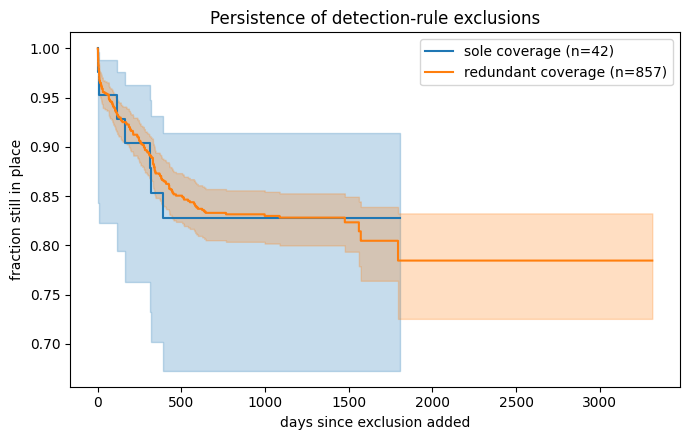

log-rank p = 0.9603   test statistic = 0.00


In [24]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

a = surv[surv.group=='singleton']
b = surv[surv.group=='redundant']

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(7,4.5))
kmf.fit(a.days, a.removed, label=f'sole coverage (n={len(a)})').plot_survival_function(ax=ax)
kmf.fit(b.days, b.removed, label=f'redundant coverage (n={len(b)})').plot_survival_function(ax=ax)
ax.set_xlabel('days since exclusion added'); ax.set_ylabel('fraction still in place')
ax.set_title('Persistence of detection-rule exclusions')
plt.tight_layout(); plt.savefig(RESULTS / 'fig3_persistence_draft.png', dpi=200)
plt.show()

r = logrank_test(a.days, b.days, a.removed, b.removed)
print(f"log-rank p = {r.p_value:.4g}   test statistic = {r.test_statistic:.2f}")

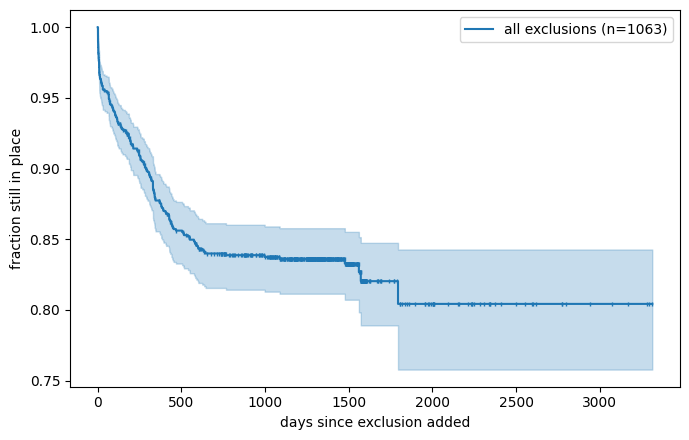

In [25]:
kmf = KaplanMeierFitter()
kmf.fit(surv.days, surv.removed, label=f'all exclusions (n={len(surv)})')
ax = kmf.plot_survival_function(figsize=(7,4.5), show_censors=True,
                                censor_styles={'ms':3,'marker':'|'})
ax.set_xlabel('days since exclusion added')
ax.set_ylabel('fraction still in place')
plt.tight_layout()

In [26]:
from lifelines import KaplanMeierFitter
from lifelines.utils import restricted_mean_survival_time as rmst

kmf = KaplanMeierFitter().fit(surv.days, surv.removed)

print("survival at fixed horizons")
for d in [30, 90, 180, 365, 730, 1095]:
    print(f"  S({d:>4}d) = {float(kmf.predict(d)):.3f}")

print(f"\nKM median survival : {kmf.median_survival_time_}")     # expect inf
print(f"RMST over 3 years  : {rmst(kmf, t=1095):.0f} days")

# how long we actually watched them (reverse KM) — needed to claim the follow-up is adequate
kmf_c = KaplanMeierFitter().fit(surv.days, 1 - surv.removed)
print(f"median follow-up   : {kmf_c.median_survival_time_:.0f} days")

# where the removals cluster
rem = surv[surv.removed == 1]
print(f"\nremovals within 180d : {100*(rem.days<=180).mean():.0f}% of all removals")
print(f"removals within 365d : {100*(rem.days<=365).mean():.0f}%")

survival at fixed horizons
  S(  30d) = 0.957
  S(  90d) = 0.943
  S( 180d) = 0.924
  S( 365d) = 0.877
  S( 730d) = 0.840
  S(1095d) = 0.836

KM median survival : inf
RMST over 3 years  : 954 days
median follow-up   : 1291 days

removals within 180d : 48% of all removals
removals within 365d : 75%


In [27]:
surv.to_csv(str(RESULTS / 'survival_suppressions.csv'), index=False)

In [28]:
import re
from collections import Counter

print(res[0]['sig_a'][:400], '\n---')          # eyeball the format first

def neg_preds(sig):
    """Full negated predicates, values included — not just field names."""
    out = set()
    for frag in sig.split('P:')[1:]:
        pred = 'P:' + frag.split('P:')[0]
        if 'CTX:NEG' in pred:
            out.add(pred.strip())
    return out

strata = Counter()
buckets = {}
for s in res:
    pos, neg = deltas(s)
    na, nb = neg_preds(s['sig_a']), neg_preds(s['sig_b'])
    if neg > 0 and pos <= 0:      k = 'P  detected suppression'
    elif neg > 0 and pos > 0:     k = 'N1 expansion-with-guard'
    elif neg == 0 and nb - na:    k = 'N2 negated values changed, count did not'
    elif neg < 0 and pos >= 0:    k = 'R  relaxation'
    else:                         k = 'N3 no exclusion change'
    strata[k] += 1
    buckets.setdefault(k, []).append(s)

for k in sorted(strata):
    print(f'{k:<42} {strata[k]:>6}')

('O:AND', (("P:EventID|EQ|('X', 1)|CTX:POS", ()), ("P:EventLog|EQ|('S', 'Microsoft-Windows-Sysmon/Operational')|CTX:POS", ()), ("P:Image|IN|('L', (('S', '*mshta'), ('S', '*msiexec'), ('S', '*regsvr32'), ('S', '*rundll32'), ('S', '*verclsid')))|CTX:POS", ()), ("P:ParentImage|EQ|('S', '*\\\\\\\\wbem\\\\\\\\WmiPrvSE.exe')|CTX:POS", ()))) 
---
N1 expansion-with-guard                       106
N2 negated values changed, count did not      957
N3 no exclusion change                       5828
P  detected suppression                      1098
R  relaxation                                 245


In [29]:
LIT = re.compile(r"\('[A-Z]',")

def val_count(sig, ctx):
    n = 0
    for frag in sig.split('P:')[1:]:
        pred = 'P:' + frag.split('P:')[0]
        if ctx in pred:
            n += len(LIT.findall(pred))
    return n

def val_deltas(s):
    return (val_count(s['sig_b'],'CTX:POS') - val_count(s['sig_a'],'CTX:POS'),
            val_count(s['sig_b'],'CTX:NEG') - val_count(s['sig_a'],'CTX:NEG'))

n2 = buckets['N2 negated values changed, count did not']
sub = Counter()
n2b = {}
for s in n2:
    dp, dn = val_deltas(s)
    k = ('value-level suppression' if dn > 0 and dp <= 0 else
         'value-level suppression + coverage growth' if dn > 0 else
         'value-level relaxation' if dn < 0 and dp >= 0 else
         'value-level relaxation + coverage loss' if dn < 0 else
         'rewrite, no net change')
    sub[k] += 1
    n2b.setdefault(k, []).append(s)

for k, v in sub.most_common():
    print(f'{k:<44} {v:>5}')

value-level suppression                        471
rewrite, no net change                         389
value-level relaxation                          46
value-level suppression + coverage growth       42
value-level relaxation + coverage loss           9


In [30]:
def show(s):
    a, b = neg_preds(s['sig_a']), neg_preds(s['sig_b'])
    print(f"--- {s['lineage_id']}  v{s['version_a']}→v{s['version_b']}")
    for p in sorted(b - a): print('   + ' + p[:150])
    for p in sorted(a - b): print('   - ' + p[:150])

for s in n2b['value-level suppression'][:5]:
    show(s)

--- lineage_00531  v1→v2
   + P:SourceImage|IN|('L', (('S', '*\\\\\\\\csrss.exe'), ('S', '*unknown process*')))|CTX:NEG", ()),)), ("
   - P:SourceImage|EQ|('S', '*\\\\\\\\csrss.exe')|CTX:NEG", ()),)), ("
--- lineage_02634  v4→v5
   + P:SourceImage|EQ|('S', '*\\\\\\\\MsMpEng.exe')|CTX:NEG", ()),)), ('O:NOT', (("
   + P:SourceImage|IN|('L', (('S', 'C:\\\\\\\\Program Files (x86)\\\\\\\\*'), ('S', 'C:\\\\\\\\Program Files\\\\\\\\*'), ('S', 'C:\\\\\\\\Windows\\\\\\\\Sy
   - P:SourceImage|EQ|('S', 'C:\\\\\\\\Windows\\\\\\\\System32\\\\\\\\csrss.exe')|CTX:NEG", ()),)), ('O:NOT', (("
   - P:SourceImage|IN|('L', (('S', '*\\\\\\\\MsMpEng.exe'), ('S', 'C:\\\\\\\\Program Files\\\\\\\\Malwarebytes\\\\\\\\Anti-Malware\\\\\\\\MBAMService.exe')
--- lineage_01890  v2→v3
   + P:Image|IN|('L', (('S', '*\\\\\\\\CCleaner Browser\\\\\\\\Application\\\\\\\\CCleanerBrowser.exe'), ('S', '*\\\\\\\\Google\\\\\\\\Chrome\\\\\\\\Applic
   - P:Image|IN|('L', (('S', '*\\\\\\\\brave.exe'), ('S', '*\\\\\\\\chrome.exe')

In [31]:
def is_suppression2(s):
    dp, dn = deltas(s); vp, vn = val_deltas(s)
    excl_grew = dn > 0 or (dn == 0 and vn > 0)
    cov_grew  = dp > 0 or (dp == 0 and vp > 0)
    return excl_grew and not cov_grew

def is_relaxation2(s):
    dp, dn = deltas(s); vp, vn = val_deltas(s)
    excl_shrank = dn < 0 or (dn == 0 and vn < 0)
    cov_shrank  = dp < 0 or (dp == 0 and vp < 0)
    return excl_shrank and not cov_shrank

sup2 = [s for s in res if is_suppression2(s)]
rel2 = [s for s in res if is_relaxation2(s)]
print(f'suppressions {len(sup2)}   relaxations {len(rel2)}   ratio {len(sup2)/max(len(rel2),1):.1f} : 1')

# what moved, and why — check nothing you already validated got dropped silently
old = {id(s) for s in sup}
print(f'  previously detected, still detected : {sum(1 for s in sup2 if id(s) in old)}')
print(f'  previously detected, now excluded   : {len(old) - sum(1 for s in sup2 if id(s) in old)}')
print(f'  newly detected (value-level)        : {sum(1 for s in sup2 if id(s) not in old)}')

suppressions 1530   relaxations 280   ratio 5.5 : 1
  previously detected, still detected : 1057
  previously detected, now excluded   : 41
  newly detected (value-level)        : 473


In [32]:
for s in n2b['rewrite, no net change'][:8]:
    show(s)          # raise the [:150] slice to [:400] in show() first

--- lineage_00243  v11→v12
   + P:_raw|CONTAINS|('S', 'File submitted to Symantec')|CTX:NEG", ()),)), ("
   - P:_raw|CONTAINS|('S', 'File submitted to Symantec for analysis')|CTX:NEG", ()),)), ("
--- lineage_00243  v12→v13
   + P:_raw|CONTAINS|('S', 'File submitted to Symantec for analysis')|CTX:NEG", ()),)), ("
   - P:_raw|CONTAINS|('S', 'File submitted to Symantec')|CTX:NEG", ()),)), ("
--- lineage_00243  v13→v14
   + P:_raw|CONTAINS|('S', 'File submitted to Symantec')|CTX:NEG", ()),)), ("
   - P:_raw|CONTAINS|('S', 'File submitted to Symantec for analysis')|CTX:NEG", ()),)), ("
--- lineage_01149  v7→v8
   + P:userIdentity.type|EQ|('S', 'AssumedRole')|CTX:NEG", ()),)), ("
   - P:type|EQ|('S', 'AssumedRole')|CTX:NEG", ()),)), ("
--- lineage_04541  v11→v12
   + P:userIdentity.arn|EQ|('S', '*requestParameters.userName*')|CTX:NEG", ()),)), ("
   - P:userIdentity.arn|EQ|('S', '*responseElements.accessKey.userName*')|CTX:NEG", ()),)), ("
--- lineage_02144  v1→v2
   + P:Location|EQ|('S', '*

In [33]:
dropped = [s for s in sup if not is_suppression2(s)]
for s in dropped[:6]:
    print(f"--- {s['lineage_id']} v{s['version_a']}→v{s['version_b']}  "
          f"pred{deltas(s)}  val{val_deltas(s)}")
    show(s)

--- lineage_00902 v22→v23  pred(0, 1)  val(1, 1)
--- lineage_00902  v22→v23
   + P:SourceParentImage|EQ|('S', '*\\\\\\\\Programs\\\\\\\\Microsoft VS Code\\\\\\\\*')|CTX:NEG", ()), ("
   + P:SourceParentImage|EQ|('S', 'C:\\\\\\\\Windows\\\\\\\\System32\\\\\\\\CompatTelRunner.exe')|CTX:NEG", ()))),)), ("
   - P:SourceParentImage|EQ|('S', '*\\\\\\\\Programs\\\\\\\\Microsoft VS Code\\\\\\\\*')|CTX:NEG", ()))),)), ("
--- lineage_03719 v5→v6  pred(0, 1)  val(1, 1)
--- lineage_03719  v5→v6
   + P:StartFunction|EQ|('S', 'EtwpNotificationThread')|CTX:NEG", ()),)), ("
--- lineage_03719 v10→v11  pred(0, 2)  val(3, 0)
--- lineage_03719  v10→v11
   + P:SourceImage|EQ|('S', '*unknown process*')|CTX:NEG", ()), ("
   + P:SourceImage|EQ|('S', 'C:\\\\\\\\Windows\\\\\\\\System32\\\\\\\\csrss.exe')|CTX:NEG", ()), ("
   + P:TargetImage|EQ|('S', 'C:\\\\\\\\Windows\\\\\\\\System32\\\\\\\\spoolsv.exe')|CTX:NEG", ()))),)), ('O:NOT', (('O:OR', (("
   - P:SourceImage|IN|('L', (('S', 'C:\\\\\\\\Program Files (x86

In [34]:
sup2 = [s for s in res if is_suppression2(s)]
rel2 = [s for s in res if is_relaxation2(s)]
print(f'suppressions {len(sup2)}   relaxations {len(rel2)}   ratio {len(sup2)/max(len(rel2),1):.1f} : 1')
print(f'  old set retained : {sum(1 for s in sup2 if id(s) in old)} / {len(sup)}')

suppressions 1530   relaxations 280   ratio 5.5 : 1
  old set retained : 1057 / 1098


In [35]:
def is_relaxation2(s):
    dp, dn = deltas(s); vp, vn = val_deltas(s)
    excl_shrank = dn < 0 or (dn == 0 and vn < 0)
    return excl_shrank and dp >= 0        # mirror of dp <= 0

rel2 = [s for s in res if is_relaxation2(s)]
print(f'suppressions {len(sup2)}   relaxations {len(rel2)}   ratio {len(sup2)/max(len(rel2),1):.1f} : 1')

suppressions 1530   relaxations 299   ratio 5.1 : 1


In [36]:
def excl_size(sig):
    return (sig.count('CTX:NEG'), val_count(sig, 'CTX:NEG'))

rows4 = []
for s in sup2:
    lid = s['lineage_id']
    t0  = date_of.get((lid, s['version_b']))
    if t0 is None:
        continue
    before = excl_size(s['sig_a'])
    later  = [x for x in by_lin[lid] if x['version_a'] >= s['version_b']]
    undone = next((x for x in later
                   if excl_size(x['sig_b'])[0] <= before[0]
                   and excl_size(x['sig_b'])[1] <= before[1]), None)
    if undone is not None:
        t1 = date_of.get((lid, undone['version_b']))
        if t1 is None:
            continue
        days, removed = (t1 - t0).total_seconds()/86400, 1
    else:
        days, removed = (SNAPSHOT - t0).total_seconds()/86400, 0

    ts  = techs(lid)
    cov = min([cover[t] for t in ts], default=None)
    rows4.append({'lineage': lid, 'suppressed_on': t0.date(), 'days': round(days,1),
                  'removed': removed, 'min_coverage': cov,
                  'group': 'singleton' if cov == 1 else ('redundant' if cov else 'untagged')})

surv = pd.DataFrame(rows4)
surv = surv[surv.days >= 1]
surv.to_csv(str(RESULTS / 'survival_suppressions.csv'), index=False)
print(len(surv), 'rows written')

1487 rows written


In [37]:
print(surv.groupby('group').agg(n=('days','size'),
                                censored=('removed', lambda x:(x==0).sum())).to_string(), '\n')

ewg = [s for s in res
       if (deltas(s)[1] > 0 or (deltas(s)[1] == 0 and val_deltas(s)[1] > 0)) and deltas(s)[0] > 0]
print('expansion-with-guard (excluded):', len(ewg))
print('value-level share of sup2      :', len(sup2) - 1098, '\n')

sing_t   = {t for t, c in cover.items() if c == 1}
sup2_lid = {s['lineage_id'] for s in sup2}
hit_sing = {t for lid in sup2_lid for t in techs(lid) if t in sing_t}
ev       = sum(1 for s in sup2 if any(t in sing_t for t in techs(s['lineage_id'])))
print(f'techniques covered {len(cover)}   singleton {len(sing_t)}')
print(f'singleton techniques suppressed {len(hit_sing)}   events {ev}')

              n  censored
group                    
redundant  1188      1019
singleton    68        61
untagged    231       210 

expansion-with-guard (excluded): 111
value-level share of sup2      : 432 

techniques covered 329   singleton 84
singleton techniques suppressed 16   events 71


In [38]:
import csv, re, pathlib
from collections import Counter

REPO = pathlib.Path(REPO)

def neg_preds_fields(sig):
    """(field, full_predicate) for every predicate carrying CTX:NEG."""
    out = []
    for frag in sig.split('P:')[1:]:
        pred = 'P:' + frag.split('P:')[0]
        if 'CTX:NEG' in pred:
            out.append((pred[2:].split('|')[0], pred.strip()))
    return out

PATTERNS = [
    (1, 'process / file identity', r'image|filename|commandline|originalfile|process(name|path)?$|'
                                   r'company|product|description|signature|imageloaded|'
                                   r'currentdirectory|startfunction|scriptblock|servicefilename|'
                                   r'objectname|details|md5|sha\d|hash|_raw|parentfolder'),
    (2, 'network identity',        r'destination|source(ip|hostname|port|address)|src_|dst_|'
                                   r'queryname|dnsquery|url|uri|http|remote|location|initiated$'),
    (3, 'account identity',        r'user|account|member|subject(domain)?name|arn|principal|'
                                   r'initiatedby|caller|logonaccount'),
    (4, 'system-assigned',         r'logonid|processid|processguid|eventid|threadid|guid|'
                                   r'sequence|recordnumber|providerguid|correlation'),
]

def classify(field):
    f = field.lower()
    for cid, name, pat in PATTERNS:
        if re.search(pat, f):
            return cid, name
    return 5, 'unclassified'

rows, tally, unk = [], Counter(), Counter()
for s in sup2:
    a = {p for _, p in neg_preds_fields(s['sig_a'])}
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a:
            continue                      # unchanged exclusion, not an addition
        cid, name = classify(field)
        tally[(cid, name)] += 1
        rows.append({'lineage': s['lineage_id'], 'version_b': s['version_b'],
                     'field': field, 'class_id': cid, 'class': name})
        if cid == 5:
            unk[field] += 1

total = sum(tally.values())
print(f'field-additions across {len(sup2)} suppressions: {total}\n')
for (cid, name), n in sorted(tally.items()):
    print(f'{cid}  {name:<28} {n:>5}  {100*n/total:5.1f}%')
infl = sum(n for (cid, _), n in tally.items() if cid in (1, 2, 3))
print(f'\nadversary-influenceable (1-3): {infl}  ({100*infl/total:.1f}%)')

with open(REPO / 'results' / 'field_classification.csv', 'w', newline='', encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=['lineage', 'version_b', 'field', 'class_id', 'class'])
    w.writeheader(); w.writerows(rows)

print('\nunclassified fields to label by hand:')
for f, n in unk.most_common():
    print(f'  {f:<40} {n}')

field-additions across 1530 suppressions: 3704

1  process / file identity       2952   79.7%
2  network identity               213    5.8%
3  account identity                43    1.2%
4  system-assigned                 12    0.3%
5  unclassified                   484   13.1%

adversary-influenceable (1-3): 3208  (86.6%)

unclassified fields to label by hand:
  TargetObject                             133
  GrantedAccess                            43
  ProcessNameBuffer                        27
  ModifyingApplication                     24
  IpAddress                                24
  ApplicationPath                          21
  Path                                     18
  ContextInfo                              17
  CallTrace                                16
  Data                                     11
  Application                              10
  ServerAddress                            10
  id.orig_h                                10
  RequestedPolicy                     

In [39]:
OVERRIDE = {
    # 1 — process / file / registry / command content
    'TargetObject':1, 'ProcessNameBuffer':1, 'ModifyingApplication':1, 'ApplicationPath':1,
    'Path':1, 'CallTrace':1, 'Application':1, 'HostApplication':1, 'PipeName':1,
    'StartModule':1, 'ParentCommand':1, 'Command':1, 'Data':11 and 1, 'Payload':1,
    'Device':1, 'Signed':1, 'CertThumbprint':1, 'ServiceName':1, 'TaskName':1,
    'LocalName':1, 'Message':1, 'ContextInfo':1,
    # 2 — network identity
    'IpAddress':2, 'id.orig_h':2, 'id.resp_h':2, 'id.resp_p':2, 'ServerAddress':2,
    'Address':2, 'IpPort':2, 'cs-referer':2, 'r-dns':2, 'service':2,
    'Query':2, 'query':2, 'qtype_name':2, 'answers':2,
    'TargetServerName':2, 'RelativeTargetName':2,
    # 3 — account identity
    'AllowedToDelegateTo':3, 'SidHistory':3,
    # 4 — system-assigned
    'Provider_Name':4, 'Provider':4, 'Channel':4, 'Level':4, 'Task':4, 'ObjectType':4,
    'ObjectClass':4, 'Feature_Name':4, 'errorCode':4, 'errorMessage':4, 'sc-status':4,
    'State':4, 'Action':4, 'rejected':4, 'Reason':4, 'PossibleCause':4,
    'CreationUtcTime':4, 'HostVersion':4,
    # 6 — operation parameters, adversary-selected
    'GrantedAccess':6, 'GrantedAcces':6, 'AccessMask':6, 'AccessList':6,
    'Protocol':6, 'IntegrityLevel':6, 'RequestedPolicy':6, 'ValidatedPolicy':6,
    'DataCondition':6, 'FilterOrigin':6, 'DeviceDetail.trusttype':6,
}
CLASS_NAME = {1:'process / file / registry content', 2:'network identity',
              3:'account identity', 4:'system-assigned', 5:'unclassified',
              6:'operation parameters'}

def classify(field):
    if field in OVERRIDE:
        cid = OVERRIDE[field]; return cid, CLASS_NAME[cid]
    f = field.lower()
    for cid, name, pat in PATTERNS:
        if re.search(pat, f):
            return cid, CLASS_NAME[cid]
    return 5, CLASS_NAME[5]

In [40]:
import csv, re, pathlib
from collections import Counter
REPO = pathlib.Path(REPO)

def neg_preds_fields(sig):
    out = []
    for frag in sig.split('P:')[1:]:
        pred = 'P:' + frag.split('P:')[0]
        if 'CTX:NEG' in pred:
            out.append((pred[2:].split('|')[0], pred.strip()))
    return out

CLASS_NAME = {1:'process / file / registry content', 2:'network identity',
              3:'account identity', 4:'system-assigned', 5:'unclassified',
              6:'operation parameters'}

PATTERNS = [
    (1, r'image|filename|commandline|originalfile|process(name|path)?$|company|product|'
        r'description|signature|imageloaded|currentdirectory|startfunction|scriptblock|'
        r'servicefilename|objectname|details|md5|sha\d|hash|_raw|parentfolder'),
    (2, r'destination|source(ip|hostname|port|address)|src_|dst_|queryname|dnsquery|'
        r'url|uri|http|remote|location|initiated$'),
    (3, r'user|account|member|subject(domain)?name|arn|principal|initiatedby|caller|logonaccount'),
    (4, r'logonid|processid|processguid|eventid|threadid|guid|sequence|recordnumber|'
        r'providerguid|correlation'),
]

OVERRIDE = {
    'TargetObject':1,'ProcessNameBuffer':1,'ModifyingApplication':1,'ApplicationPath':1,
    'Path':1,'CallTrace':1,'Application':1,'HostApplication':1,'PipeName':1,'StartModule':1,
    'ParentCommand':1,'Command':1,'Data':1,'Payload':1,'Device':1,'Signed':1,
    'CertThumbprint':1,'ServiceName':1,'TaskName':1,'LocalName':1,'Message':1,'ContextInfo':1,
    'IpAddress':2,'id.orig_h':2,'id.resp_h':2,'id.resp_p':2,'ServerAddress':2,'Address':2,
    'IpPort':2,'cs-referer':2,'r-dns':2,'service':2,'Query':2,'query':2,'qtype_name':2,
    'answers':2,'TargetServerName':2,'RelativeTargetName':2,
    'AllowedToDelegateTo':3,'SidHistory':3,
    'Provider_Name':4,'Provider':4,'Channel':4,'Level':4,'Task':4,'ObjectType':4,
    'ObjectClass':4,'Feature_Name':4,'errorCode':4,'errorMessage':4,'sc-status':4,'State':4,
    'Action':4,'rejected':4,'Reason':4,'PossibleCause':4,'CreationUtcTime':4,'HostVersion':4,
    'GrantedAccess':6,'GrantedAcces':6,'AccessMask':6,'AccessList':6,'Protocol':6,
    'IntegrityLevel':6,'RequestedPolicy':6,'ValidatedPolicy':6,'DataCondition':6,
    'FilterOrigin':6,'DeviceDetail.trusttype':6,'param1':6,'responseElements':6,
}

def classify(field):
    if field in OVERRIDE:
        return OVERRIDE[field], CLASS_NAME[OVERRIDE[field]]
    f = field.lower()
    for cid, pat in PATTERNS:
        if re.search(pat, f):
            return cid, CLASS_NAME[cid]
    return 5, CLASS_NAME[5]

rows, tally, unk = [], Counter(), Counter()
for s in sup2:
    a = {p for _, p in neg_preds_fields(s['sig_a'])}
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a:
            continue
        cid, name = classify(field)
        tally[(cid, name)] += 1
        rows.append({'lineage': s['lineage_id'], 'version_b': s['version_b'],
                     'field': field, 'class_id': cid, 'class': name})
        if cid == 5:
            unk[field] += 1

total = sum(tally.values())
print(f'field-additions across {len(sup2)} suppressions: {total}\n')
for (cid, name), n in sorted(tally.items()):
    print(f'{cid}  {name:<34} {n:>5}  {100*n/total:5.1f}%')
infl = sum(n for (cid, _), n in tally.items() if cid in (1, 2, 3, 6))
print(f'\nadversary-influenceable (1,2,3,6): {infl}  ({100*infl/total:.1f}%)')
print(f'system-assigned (4)              : {tally[(4, CLASS_NAME[4])]}')

with open(REPO/'results'/'field_classification.csv','w',newline='',encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=['lineage','version_b','field','class_id','class'])
    w.writeheader(); w.writerows(rows)

print(f'\nstill unclassified: {sum(unk.values())} additions across {len(unk)} fields')
for f, n in unk.most_common(20):
    print(f'  {f:<40} {n}')

field-additions across 1530 suppressions: 3704

1  process / file / registry content   3251   87.8%
2  network identity                     281    7.6%
3  account identity                      46    1.2%
4  system-assigned                       47    1.3%
6  operation parameters                  79    2.1%

adversary-influenceable (1,2,3,6): 3657  (98.7%)
system-assigned (4)              : 47

still unclassified: 0 additions across 0 fields


In [41]:
import re
from collections import Counter

PROT = re.compile(r'^[a-z]:\\(windows|program files( \(x86\))?|programdata\\microsoft)\\', re.I)
USERW = re.compile(r'users\\|\\appdata\\|\\temp\\|\\tmp\\|\\downloads\\|\\public\\', re.I)
FILEISH = {1}

def literals(pred):
    return re.findall(r"\('[A-Z]',\s*'([^']*)'\)", pred)

def norm(v):
    return re.sub(r'\\{2,}', r'\\', v)

def anchor(v):
    v = norm(v).strip()
    if not v:                       return 'empty'
    if USERW.search(v):             return 'user-writable path'
    if v.startswith('*') or '\\' not in v.rstrip('*'):
        return 'bare name or suffix'
    if PROT.match(v):               return 'protected path'
    return 'other absolute path'

anc = Counter()
for s in sup2:
    a = {p for _, p in neg_preds_fields(s['sig_a'])}
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(field)[0] not in FILEISH:
            continue
        for v in literals(pred):
            anc[anchor(v)] += 1

t = sum(anc.values())
print(f'path/file exclusion values examined: {t}\n')
for k, n in anc.most_common():
    print(f'  {k:<24} {n:>5}  {100*n/t:5.1f}%')
free = anc['bare name or suffix'] + anc['user-writable path']
print(f'\nenterable without privilege: {free}  ({100*free/t:.1f}%)')

path/file exclusion values examined: 7026

  bare name or suffix       4675   66.5%
  protected path            1764   25.1%
  user-writable path         411    5.8%
  other absolute path        166    2.4%
  empty                       10    0.1%

enterable without privilege: 5086  (72.4%)


In [42]:
import random
samples = {k: [] for k in anc}
for s in sup2:
    a = {p for _, p in neg_preds_fields(s['sig_a'])}
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(field)[0] != 1:
            continue
        for v in literals(pred):
            samples[anchor(v)].append((field, norm(v)))

for k in ['bare name or suffix', 'protected path', 'user-writable path', 'other absolute path']:
    print(f'\n=== {k}  (n={len(samples[k])})')
    for f, v in random.sample(samples[k], min(12, len(samples[k]))):
        print(f'   {f:<22} {v[:90]}')


=== bare name or suffix  (n=4675)
   Image                  *peazip*
   Image                  *\tiworker.exe
   Image                  *C:\Windows\System32\DeviceCensus.exe
   SourceImage            *\Microsoft VS Code\Code.exe
   Image                  *\firefox.exe
   Data                   *HostApplication=C:\Windows\SysWOW64\WindowsPowerShell\v1.0\powershell*
   Image                  *\Services\Microsoft.VisualStudio.Setup.Service\BackgroundDownload.exe
   ParentImage            *\setup.exe
   Image                  *\sqlservr.exe
   CommandLine            * wuaueng.dll *
   Image                  *:\WINDOWS\System32\sdiagnhost.exe
   ParentCommandLine      *-k LocalSystemNetworkRestricted -p -s NgcSvc*

=== protected path  (n=1764)
   ImageLoaded            C:\Windows\Installer\*
   ProcessName            C:\Program Files (x86)\Microsoft\*
   Image                  C:\Program Files (x86)\Google\Chrome\Application\chrome.exe
   Image                  C:\Windows\System32\taskhost

In [43]:
PATH_FIELDS = {'Image','ParentImage','SourceImage','TargetImage','SourceParentImage',
               'TargetFilename','ImageLoaded','ProcessName','ParentProcessName',
               'ApplicationPath','ModifyingApplication','Path','ProcessNameBuffer',
               'ServiceFileName','CurrentDirectory','Application','HostApplication',
               'OriginalFileName','LocalName','Device'}

ABS      = re.compile(r'^\*?[a-z]:\\', re.I)
SYSROOT  = re.compile(r'^\*?(\\systemroot\\|%systemroot%|%windir%|%programfiles)', re.I)
PROT     = re.compile(r'^\*?([a-z]:)?\\?(windows|program files( \(x86\))?)\\', re.I)
USERW    = re.compile(r'users\\|\\appdata\\|\\temp\\|\\tmp\\|\\downloads\\|\\public\\|'
                      r'%temp%|%appdata%|%localappdata%|%userprofile%', re.I)
REG      = re.compile(r'\\registry\\|^hk(ey|lm|cu)', re.I)

def anchor(v):
    v = norm(v).strip()
    if not v:            return 'empty'
    if REG.search(v):    return 'registry path'
    if USERW.search(v):  return 'user-writable path'
    if SYSROOT.match(v): return 'protected path'
    if ABS.match(v):     return 'protected path' if PROT.match(v) else 'other absolute path'
    if v.startswith('*') or '\\' not in v.rstrip('*'):
        return 'bare name or suffix'
    return 'other relative path'

anc, content = Counter(), Counter()
for s in sup2:
    a = {p for _, p in neg_preds_fields(s['sig_a'])}
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(field)[0] != 1:
            continue
        for v in literals(pred):
            (anc if field in PATH_FIELDS else content)[
                anchor(v) if field in PATH_FIELDS else field] += 1

t = sum(anc.values())
print(f'PATH-VALUED exclusion values: {t}\n')
for k, n in anc.most_common():
    print(f'  {k:<24} {n:>5}  {100*n/t:5.1f}%')
free = anc['bare name or suffix'] + anc['user-writable path']
print(f'\nenterable without privilege: {free}  ({100*free/t:.1f}%)')
print(f'requires privileged write  : {anc["protected path"]}  ({100*anc["protected path"]/t:.1f}%)')

print(f'\nCONTENT-VALUED exclusions (reported separately): {sum(content.values())}')
for f, n in content.most_common(10):
    print(f'  {f:<24} {n}')

PATH-VALUED exclusion values: 5357

  bare name or suffix       2971   55.5%
  protected path            1875   35.0%
  user-writable path         352    6.6%
  other absolute path        144    2.7%
  other relative path          8    0.1%
  empty                        7    0.1%

enterable without privilege: 3323  (62.0%)
requires privileged write  : 1875  (35.0%)

CONTENT-VALUED exclusions (reported separately): 1669
  CommandLine              568
  TargetObject             458
  ParentCommandLine        147
  Details                  147
  Data                     57
  _raw                     51
  ScriptBlockText          46
  ContextInfo              41
  FileNameBuffer           36
  CallTrace                20


In [44]:
import csv, random, pathlib
random.seed(20260820)

REPO = pathlib.Path(REPO)
VAL  = REPO / 'results' / 'validation'; VAL.mkdir(parents=True, exist_ok=True)

def pos_preds(sig):
    out = set()
    for frag in sig.split('P:')[1:]:
        p = 'P:' + frag.split('P:')[0]
        if 'CTX:POS' in p: out.add(p.strip())
    return out
def neg_set(sig):
    return {p for _, p in neg_preds_fields(sig)}

def stratum(s):
    dp, dn = deltas(s); vp, vn = val_deltas(s)
    if (dn > 0 or (dn == 0 and vn > 0)) and dp > 0:      return 'expansion-with-guard'
    if is_relaxation2(s):                                 return 'relaxation'
    if neg_set(s['sig_a']) != neg_set(s['sig_b']):        return 'rewrite, no net change'
    return 'no exclusion change'

negs = {}
for s in res:
    if is_suppression2(s): continue
    negs.setdefault(stratum(s), []).append(s)
sizes = {k: len(v) for k, v in negs.items()}
print('negative strata:', sizes)

items = [('pos', 'detected', s) for s in random.sample(sup2, 60)]
for k, v in negs.items():
    items += [('neg', k, s) for s in random.sample(v, min(15, len(v)))]
random.shuffle(items)

def block(s):
    na, nb = neg_set(s['sig_a']), neg_set(s['sig_b'])
    pa, pb = pos_preds(s['sig_a']), pos_preds(s['sig_b'])
    L = []
    for tag, ss in (('EXCLUSION  +', nb-na), ('EXCLUSION  -', na-nb),
                    ('SELECTION  +', pb-pa), ('SELECTION  -', pa-pb)):
        for p in sorted(ss)[:8]:
            L.append(f'{tag} {p[:220]}')
    return L or ['(no predicate-level change)']

md, key, blank = ['# Validation worksheet\n',
                  'Label each item **S** (a suppression: the exclusion set genuinely widened '
                  'and coverage did not) or **N** (not a suppression) or **U** (unclear).\n',
                  'Commit messages are deliberately withheld so the corroboration measure '
                  'stays independent.\n'], [], []
for n, (arm, strat, s) in enumerate(items, 1):
    iid = f'V{n:03d}'
    md.append(f'\n---\n\n## {iid}\n\n```')
    md += block(s)
    md.append('```\n')
    key.append({'item_id': iid, 'lineage': s['lineage_id'], 'version_a': s['version_a'],
                'version_b': s['version_b'], 'arm': arm, 'stratum': strat,
                'stratum_size': sizes.get(strat, len(sup2)), 'n_detected': len(sup2)})
    blank.append({'item_id': iid, 'label': '', 'notes': ''})

(VAL/'worksheet.md').write_text('\n'.join(md), encoding='utf-8')
for name, rows, cols in (('sample_key.csv', key, list(key[0])),
                         ('sample_labels.csv', blank, ['item_id','label','notes'])):
    with open(VAL/name, 'w', newline='', encoding='utf-8') as fh:
        w = csv.DictWriter(fh, fieldnames=cols); w.writeheader(); w.writerows(rows)

print(f'{len(items)} items written to results/validation/')

negative strata: {'no exclusion change': 5783, 'rewrite, no net change': 511, 'relaxation': 299, 'expansion-with-guard': 111}
120 items written to results/validation/


In [45]:
CUT = re.compile(r'^P:.*?CTX:(?:POS|NEG)', re.S)

def _clean(p):
    m = CUT.match(p)
    return m.group(0) if m else p.strip()

def neg_preds_fields(sig):
    out = []
    for frag in sig.split('P:')[1:]:
        p = _clean('P:' + frag.split('P:')[0])
        if p.endswith('CTX:NEG'):
            out.append((p[2:].split('|')[0], p))
    return out

def pos_preds(sig):
    out = set()
    for frag in sig.split('P:')[1:]:
        p = _clean('P:' + frag.split('P:')[0])
        if p.endswith('CTX:POS'):
            out.add(p)
    return out

def neg_set(sig):
    return {p for _, p in neg_preds_fields(sig)}

# sanity: an unchanged predicate must now compare equal
x = res[0]
print('spurious diffs before/after fix — should be 0 for identical predicates:')
print(len(neg_set(x['sig_a']) ^ neg_set(x['sig_b'])), 'symmetric difference on', x['lineage_id'])

spurious diffs before/after fix — should be 0 for identical predicates:
0 symmetric difference on lineage_04342


In [46]:
import csv, pathlib
from collections import Counter
REPO = pathlib.Path(REPO)

# ---- 5.1 field taxonomy -------------------------------------------------
rows, tally, unk = [], Counter(), Counter()
for s in sup2:
    a = neg_set(s['sig_a'])
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a:
            continue
        cid, name = classify(field)
        tally[(cid, name)] += 1
        rows.append({'lineage': s['lineage_id'], 'version_b': s['version_b'],
                     'field': field, 'class_id': cid, 'class': name})
        if cid == 5:
            unk[field] += 1

total = sum(tally.values())
print(f'field-additions across {len(sup2)} suppressions: {total}\n')
for (cid, name), n in sorted(tally.items()):
    print(f'{cid}  {name:<34} {n:>5}  {100*n/total:5.1f}%')
infl = sum(n for (cid, _), n in tally.items() if cid in (1, 2, 3, 6))
print(f'\nadversary-influenceable (1,2,3,6): {infl}  ({100*infl/total:.1f}%)')
print(f'still unclassified: {sum(unk.values())} across {len(unk)} fields')

with open(REPO/'results'/'field_classification.csv','w',newline='',encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=['lineage','version_b','field','class_id','class'])
    w.writeheader(); w.writerows(rows)

# ---- 5.2 path anchors ---------------------------------------------------
anc, content = Counter(), Counter()
for s in sup2:
    a = neg_set(s['sig_a'])
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(field)[0] != 1:
            continue
        if field in PATH_FIELDS:
            for v in literals(pred):
                anc[anchor(v)] += 1
        else:
            content[field] += len(literals(pred))

t = sum(anc.values())
print(f'\nPATH-VALUED exclusion values: {t}\n')
for k, n in anc.most_common():
    print(f'  {k:<24} {n:>5}  {100*n/t:5.1f}%')
free = anc['bare name or suffix'] + anc['user-writable path']
print(f'\nenterable without privilege: {free}  ({100*free/t:.1f}%)')
print(f'requires privileged write  : {anc["protected path"]}  ({100*anc["protected path"]/t:.1f}%)')
print(f'\nCONTENT-VALUED exclusions: {sum(content.values())}')
for f, n in content.most_common(10):
    print(f'  {f:<24} {n}')

field-additions across 1530 suppressions: 3279

1  process / file / registry content   2864   87.3%
2  network identity                     268    8.2%
3  account identity                      37    1.1%
4  system-assigned                       36    1.1%
6  operation parameters                  74    2.3%

adversary-influenceable (1,2,3,6): 3243  (98.9%)
still unclassified: 0 across 0 fields

PATH-VALUED exclusion values: 4722

  bare name or suffix       2636   55.8%
  protected path            1651   35.0%
  user-writable path         302    6.4%
  other absolute path        119    2.5%
  other relative path          8    0.2%
  empty                        6    0.1%

enterable without privilege: 2938  (62.2%)
requires privileged write  : 1651  (35.0%)

CONTENT-VALUED exclusions: 1519
  CommandLine              520
  TargetObject             417
  ParentCommandLine        138
  Details                  122
  Data                     57
  _raw                     47
  ContextInfo    

In [47]:
import csv, random, pathlib
random.seed(20260820)
VAL = pathlib.Path(str(RESULTS / 'validation'))
VAL.mkdir(parents=True, exist_ok=True)

def stratum(s):
    dp, dn = deltas(s); vp, vn = val_deltas(s)
    if (dn > 0 or (dn == 0 and vn > 0)) and dp > 0:  return 'expansion-with-guard'
    if is_relaxation2(s):                             return 'relaxation'
    if neg_set(s['sig_a']) != neg_set(s['sig_b']):    return 'rewrite, no net change'
    return 'no exclusion change'

negs = {}
for s in res:
    if not is_suppression2(s):
        negs.setdefault(stratum(s), []).append(s)
sizes = {k: len(v) for k, v in negs.items()}
print('negative strata:', sizes)

items = [('pos', 'detected', s) for s in random.sample(sup2, 60)]
for k, v in negs.items():
    items += [('neg', k, s) for s in random.sample(v, min(15, len(v)))]
random.shuffle(items)

def block(s):
    na, nb = neg_set(s['sig_a']), neg_set(s['sig_b'])
    pa, pb = pos_preds(s['sig_a']), pos_preds(s['sig_b'])
    L = []
    for tag, ss in (('EXCLUSION  +', nb-na), ('EXCLUSION  -', na-nb),
                    ('SELECTION  +', pb-pa), ('SELECTION  -', pa-pb)):
        for p in sorted(ss)[:8]:
            L.append(f'{tag} {norm(p)[:220]}')
    return L or ['(no predicate-level change)']

md = ['# Validation worksheet\n',
      'Label each item **S** (a suppression: the exclusion set genuinely widened and '
      'coverage did not), **N** (not a suppression), or **U** (unclear).\n',
      'Commit messages are withheld so the corroboration measure stays independent.\n']
key, blank = [], []
for n, (arm, strat, s) in enumerate(items, 1):
    iid = f'V{n:03d}'
    md.append(f'\n---\n\n## {iid}\n\n```')
    md += block(s)
    md.append('```\n')
    key.append({'item_id': iid, 'lineage': s['lineage_id'], 'version_a': s['version_a'],
                'version_b': s['version_b'], 'arm': arm, 'stratum': strat,
                'stratum_size': sizes.get(strat, len(sup2)), 'n_detected': len(sup2)})
    blank.append({'item_id': iid, 'label': '', 'notes': ''})

(VAL/'worksheet.md').write_text('\n'.join(md), encoding='utf-8')
for name, rows_, cols in (('sample_key.csv', key, list(key[0])),
                          ('sample_labels.csv', blank, ['item_id','label','notes'])):
    with open(VAL/name, 'w', newline='', encoding='utf-8') as fh:
        w = csv.DictWriter(fh, fieldnames=cols); w.writeheader(); w.writerows(rows_)
print(f'{len(items)} items written')

negative strata: {'no exclusion change': 5852, 'rewrite, no net change': 442, 'relaxation': 299, 'expansion-with-guard': 111}
120 items written


In [48]:
BY = {(x['lineage_id'], str(x['version_a']), str(x['version_b'])): x for x in res}

def full(iid):
    k = KEY[iid]
    s = BY[(k['lineage'], str(k['version_a']), str(k['version_b']))]
    na, nb = neg_set(s['sig_a']), neg_set(s['sig_b'])
    pa, pb = pos_preds(s['sig_a']), pos_preds(s['sig_b'])
    for tag, ss in (('EXCLUSION  +', nb-na), ('EXCLUSION  -', na-nb),
                    ('SELECTION  +', pb-pa), ('SELECTION  -', pa-pb)):
        for p in sorted(ss):
            print('   ', tag, norm(p))

In [49]:
import csv
KEY = {r['item_id']: r for r in csv.DictReader(open(VAL/'sample_key.csv', encoding='utf-8'))}
LAB = {r['item_id']: r['label'].strip().upper()
       for r in csv.DictReader(open(VAL/'sample_labels.csv', encoding='utf-8'))}

dis = [(i, KEY[i]['arm'], KEY[i]['stratum'], LAB.get(i,'')) for i in KEY
       if (KEY[i]['arm']=='pos' and LAB.get(i)=='N') or (KEY[i]['arm']=='neg' and LAB.get(i)=='S')]
print(f'{len(dis)} disagreements\n')
for i, arm, st, l in dis:
    print(f'\n=== {i}   detector said {"S" if arm=="pos" else "N"}   ({st})   you said {l}')
    full(i)

0 disagreements



In [50]:
for i, arm, st, l in dis:
    k = KEY[i]
    s = BY[(k['lineage'], str(k['version_a']), str(k['version_b']))]
    na, nb = neg_set(s['sig_a']), neg_set(s['sig_b'])
    pa, pb = pos_preds(s['sig_a']), pos_preds(s['sig_b'])
    print(f'{i}  det={"S" if arm=="pos" else "N"}  you={l:<2} {st[:22]:<22} '
          f'excl +{len(nb-na)}/-{len(na-nb)}   sel +{len(pb-pa)}/-{len(pa-pb)}')

In [51]:
d = sum(1 for s in res if s['sig_a'].count('CTX:NEG') != len(neg_set(s['sig_a'])))
print(d, 'of', len(res), 'steps have duplicate NEG predicates')

270 of 8234 steps have duplicate NEG predicates


In [52]:
import sys
sys.path.insert(0, str(REPO / 'src'))
from detector import *

sup2 = [s for s in res if is_suppression(s)]
rel2 = [s for s in res if is_relaxation(s)]
print(f'suppressions {len(sup2)}   relaxations {len(rel2)}   '
      f'ratio {len(sup2)/max(len(rel2),1):.1f} : 1')

from collections import Counter
print(Counter(stratum(s) for s in res if not is_suppression(s)))

suppressions 1642   relaxations 304   ratio 5.4 : 1
Counter({'no exclusion change': 5861, 'rewrite, no net change': 354, 'relaxation': 304, 'expansion-with-guard': 73})


In [53]:
import pandas as pd
rows4 = []
for s in sup2:
    lid = s['lineage_id']
    t0  = date_of.get((lid, s['version_b']))
    if t0 is None:
        continue
    before = excl_size(s['sig_a'])
    later  = [x for x in by_lin[lid] if x['version_a'] >= s['version_b']]
    undone = next((x for x in later
                   if excl_size(x['sig_b'])[0] <= before[0]
                   and excl_size(x['sig_b'])[1] <= before[1]), None)
    if undone is not None:
        t1 = date_of.get((lid, undone['version_b']))
        if t1 is None:
            continue
        days, removed = (t1 - t0).total_seconds()/86400, 1
    else:
        days, removed = (SNAPSHOT - t0).total_seconds()/86400, 0
    ts  = techs(lid)
    cov = min([cover[t] for t in ts], default=None)
    rows4.append({'lineage': lid, 'suppressed_on': t0.date(), 'days': round(days,1),
                  'removed': removed, 'min_coverage': cov,
                  'group': 'singleton' if cov == 1 else ('redundant' if cov else 'untagged')})

surv = pd.DataFrame(rows4); surv = surv[surv.days >= 1]
surv.to_csv(str(RESULTS / 'survival_suppressions.csv'), index=False)
print(len(surv), 'rows')
print(surv.groupby('group').agg(n=('days','size'), censored=('removed', lambda x:(x==0).sum())).to_string())

1584 rows
              n  censored
group                    
redundant  1268      1093
singleton    71        63
untagged    245       225


In [54]:
from forgeability import report
report(sup2, results_dir=str(RESULTS))

field-additions across 1642 suppressions: 3606

1  process / file / registry content   3101   86.0%
2  network identity                     362   10.0%
3  account identity                      38    1.1%
4  system-assigned                       39    1.1%
6  operation parameters                  66    1.8%

adversary-influenceable (1,2,3,6): 3567  (98.9%)
unclassified: 0

PATH-VALUED exclusion values: 5336

  bare name or suffix       3105   58.2%
  protected path            1759   33.0%
  user-writable path         316    5.9%
  other absolute path        128    2.4%
  empty                       21    0.4%
  other relative path          7    0.1%

enterable without privilege: 3421  (64.1%)
requires privileged write  : 1759  (33.0%)

CONTENT-VALUED exclusions: 1573
  CommandLine              576
  TargetObject             422
  ParentCommandLine        143
  Details                  138
  Data                     51
  _raw                     47
  ContextInfo              40
  ScriptB

(Counter({(1, 'process / file / registry content'): 3101,
          (2, 'network identity'): 362,
          (6, 'operation parameters'): 66,
          (4, 'system-assigned'): 39,
          (3, 'account identity'): 38}),
 Counter({'bare name or suffix': 3105,
          'protected path': 1759,
          'user-writable path': 316,
          'other absolute path': 128,
          'empty': 21,
          'other relative path': 7}),
 Counter({'CommandLine': 576,
          'TargetObject': 422,
          'ParentCommandLine': 143,
          'Details': 138,
          'Data': 51,
          '_raw': 47,
          'ContextInfo': 40,
          'ScriptBlockText': 40,
          'FileNameBuffer': 38,
          'CallTrace': 20,
          'StartFunction': 10,
          'SignatureStatus': 8,
          'SourceCommandLine': 5,
          'PipeName': 5,
          'ObjectName': 4,
          'Signed': 3,
          'Payload': 3,
          'Commandline': 3,
          'TaskName': 3,
          'StartModule': 2,
      

In [55]:
import importlib, forgeability
importlib.reload(forgeability)
forgeability.report(sup2, results_dir=str(RESULTS))

field-additions across 1642 suppressions: 3606

1  process / file / registry content   3101   86.0%
2  network identity                     362   10.0%
3  account identity                      38    1.1%
4  system-assigned                       39    1.1%
6  operation parameters                  66    1.8%

adversary-influenceable (1,2,3,6): 3567  (98.9%)
unclassified: 0

PATH-VALUED exclusion values: 5336

  bare name or suffix       3105   58.2%
  protected path            1759   33.0%
  user-writable path         316    5.9%
  other absolute path        128    2.4%
  empty                       21    0.4%
  other relative path          7    0.1%

enterable without privilege: 3421  (64.1%)
requires privileged write  : 1759  (33.0%)

CONTENT-VALUED exclusions: 1573
  CommandLine              576
  TargetObject             422
  ParentCommandLine        143
  Details                  138
  Data                     51
  _raw                     47
  ContextInfo              40
  ScriptB

(Counter({(1, 'process / file / registry content'): 3101,
          (2, 'network identity'): 362,
          (6, 'operation parameters'): 66,
          (4, 'system-assigned'): 39,
          (3, 'account identity'): 38}),
 Counter({'bare name or suffix': 3105,
          'protected path': 1759,
          'user-writable path': 316,
          'other absolute path': 128,
          'empty': 21,
          'other relative path': 7}),
 Counter({'CommandLine': 576,
          'TargetObject': 422,
          'ParentCommandLine': 143,
          'Details': 138,
          'Data': 51,
          '_raw': 47,
          'ContextInfo': 40,
          'ScriptBlockText': 40,
          'FileNameBuffer': 38,
          'CallTrace': 20,
          'StartFunction': 10,
          'SignatureStatus': 8,
          'SourceCommandLine': 5,
          'PipeName': 5,
          'ObjectName': 4,
          'Signed': 3,
          'Payload': 3,
          'Commandline': 3,
          'TaskName': 3,
          'StartModule': 2,
      

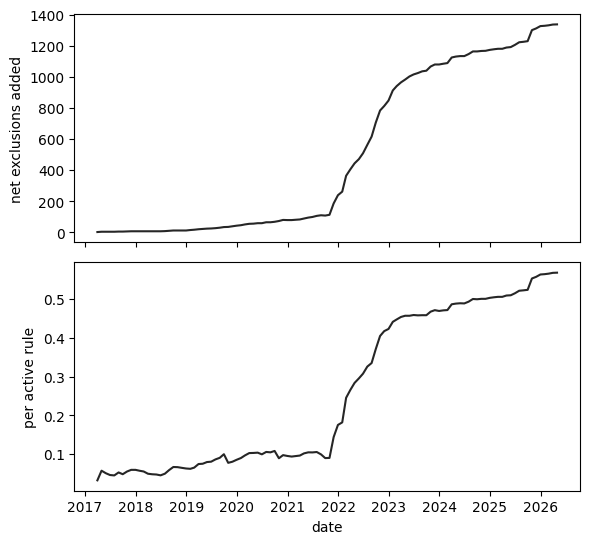

In [56]:
import pandas as pd, matplotlib.pyplot as plt

ev = ([{'d': date_of[(s['lineage_id'], s['version_b'])], 'x': 1} for s in sup2
       if (s['lineage_id'], s['version_b']) in date_of] +
      [{'d': date_of[(s['lineage_id'], s['version_b'])], 'x': -1} for s in rel2
       if (s['lineage_id'], s['version_b']) in date_of])
e = pd.DataFrame(ev).set_index('d').sort_index()
m = e.resample('ME').x.sum().cumsum()

# rules alive each month, to separate the ratchet from corpus growth
# first commit date per lineage, in one pass over date_of; the obvious
# nested form is quadratic and takes minutes on this corpus
first_seen = {}
for (l, v), d in date_of.items():
    if l not in first_seen or d < first_seen[l]:
        first_seen[l] = d
births = pd.Series(1, index=sorted(first_seen[lid]
                                   for lid in {s['lineage_id'] for s in res}))
alive = births.resample('ME').sum().cumsum().reindex(m.index, method='ffill')

fig, ax = plt.subplots(2, 1, figsize=(6, 5.5), sharex=True)
ax[0].plot(m.index, m.values, color='0.15'); ax[0].set_ylabel('net exclusions added')
ax[1].plot(m.index, (m/alive).values, color='0.15'); ax[1].set_ylabel('per active rule')
ax[1].set_xlabel('date'); plt.tight_layout()

In [57]:
from collections import Counter
import pandas as pd

dts = [date_of[(s['lineage_id'], s['version_b'])] for s in sup2
       if (s['lineage_id'], s['version_b']) in date_of]

byday = Counter(d.date() for d in dts)
print('busiest days:')
for d, n in byday.most_common(12):
    print(f'  {d}  {n:>4}   ({100*n/len(dts):.1f}% of all suppressions)')

top20 = sum(n for _, n in byday.most_common(20))
print(f'\ntop 20 days account for {top20} of {len(dts)} suppressions ({100*top20/len(dts):.0f}%)')

s = pd.Series(1, index=pd.DatetimeIndex(dts)).sort_index()
surge = s['2021-10':'2023-01'].sum()
print(f'Oct 2021 - Jan 2023 window: {surge} ({100*surge/len(dts):.0f}%)')
print(f'distinct lineages contributing: {len({x["lineage_id"] for x in sup2})}')

busiest days:
  2025-10-09    50   (3.0% of all suppressions)
  2022-09-21    30   (1.8% of all suppressions)
  2023-11-15    20   (1.2% of all suppressions)
  2022-02-16    17   (1.0% of all suppressions)
  2022-02-21    16   (1.0% of all suppressions)
  2022-09-18    15   (0.9% of all suppressions)
  2024-03-13    15   (0.9% of all suppressions)
  2025-12-09    14   (0.9% of all suppressions)
  2024-03-11    14   (0.9% of all suppressions)
  2022-10-07    13   (0.8% of all suppressions)
  2022-09-20    13   (0.8% of all suppressions)
  2025-10-17    13   (0.8% of all suppressions)

top 20 days account for 326 of 1642 suppressions (20%)
Oct 2021 - Jan 2023 window: 948 (58%)
distinct lineages contributing: 524


In [58]:
s = pd.Series(1, index=pd.DatetimeIndex(dts)).sort_index()
surge = s['2021-10':'2023-01'].sum()
print(f'Oct 2021 - Jan 2023: {surge} ({100*surge/len(dts):.0f}%)')
print(f'distinct lineages contributing: {len({x["lineage_id"] for x in sup2})}')

Oct 2021 - Jan 2023: 948 (58%)
distinct lineages contributing: 524


In [59]:
busy = {d for d, _ in byday.most_common(20)}
def dt(x): return date_of.get((x['lineage_id'], x['version_b']))
sup_q = [x for x in sup2 if dt(x) and dt(x).date() not in busy]
rel_q = [x for x in rel2 if dt(x) and dt(x).date() not in busy]
print(f'excluding the 20 busiest days: {len(sup_q)} / {len(rel_q)} = '
      f'{len(sup_q)/max(len(rel_q),1):.1f} : 1   (headline 5.4 : 1)')

excluding the 20 busiest days: 1316 / 268 = 4.9 : 1   (headline 5.4 : 1)


rule age at suppression (days):  median 492   mean 613
  25th percentile: 105
  50th percentile: 492
  75th percentile: 956
  90th percentile: 1379

within 90 days of rule creation : 24%
within 1 year                   : 44%


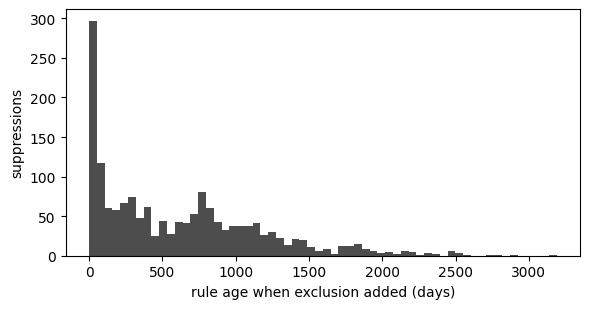

In [60]:
import numpy as np
birth = {}
for (lid, v), d in date_of.items():
    if lid not in birth or d < birth[lid]:
        birth[lid] = d

age = [ (date_of[(s['lineage_id'], s['version_b'])] - birth[s['lineage_id']]).days
        for s in sup2 if (s['lineage_id'], s['version_b']) in date_of ]
age = np.array([a for a in age if a >= 0])

print(f'rule age at suppression (days):  median {np.median(age):.0f}   '
      f'mean {age.mean():.0f}')
for q in [25, 50, 75, 90]:
    print(f'  {q}th percentile: {np.percentile(age, q):.0f}')
print(f'\nwithin 90 days of rule creation : {100*(age<=90).mean():.0f}%')
print(f'within 1 year                   : {100*(age<=365).mean():.0f}%')

import matplotlib.pyplot as plt
plt.figure(figsize=(6,3.2))
plt.hist(age, bins=60, color='0.3')
plt.xlabel('rule age when exclusion added (days)'); plt.ylabel('suppressions')
plt.tight_layout(); plt.show()

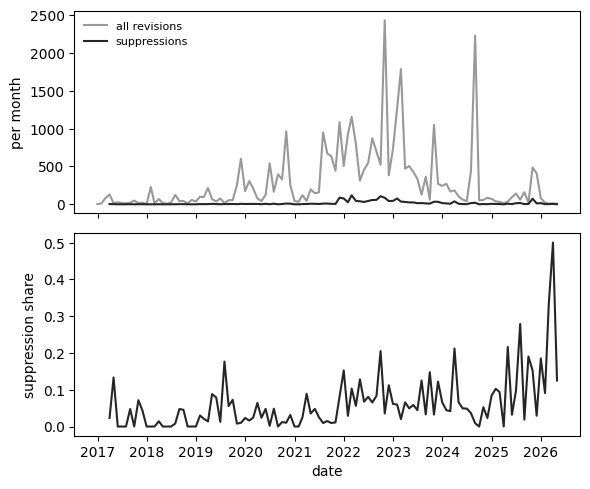

0.08326723939079772 vs 0.057883027251294246


In [61]:
import pandas as pd
allm = pd.Series(1, index=pd.DatetimeIndex(
        [d for (_, _), d in date_of.items()])).sort_index().resample('ME').sum()
supm = pd.Series(1, index=pd.DatetimeIndex(dts)).sort_index().resample('ME').sum()
frac = (supm / allm.reindex(supm.index)).dropna()

fig, ax = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
ax[0].plot(allm.index, allm.values, color='0.6', label='all revisions')
ax[0].plot(supm.index, supm.values, color='0.15', label='suppressions')
ax[0].legend(frameon=False, fontsize=8); ax[0].set_ylabel('per month')
ax[1].plot(frac.index, frac.values, color='0.15')
ax[1].set_ylabel('suppression share'); ax[1].set_xlabel('date')
plt.tight_layout(); plt.show()

print(frac['2021-10':'2023-01'].mean(), 'vs', frac.drop(frac['2021-10':'2023-01'].index).mean())

In [62]:
tail = pd.DataFrame({'all': allm.reindex(frac.index), 'sup': supm, 'share': frac})
print(tail.tail(20).to_string())

ok = tail[tail['all'] >= 50]          # months with a usable denominator
from scipy.stats import spearmanr
r, p = spearmanr(range(len(ok)), ok['share'])
print(f'\nmonths with >=50 revisions: {len(ok)}')
print(f'Spearman trend in suppression share: rho = {r:.3f}, p = {p:.4g}')
print(f'first half mean {ok["share"][:len(ok)//2].mean():.3f}   '
      f'second half mean {ok["share"][len(ok)//2:].mean():.3f}')

                           all  sup     share
2024-09-30 00:00:00+00:00   52    0  0.000000
2024-10-31 00:00:00+00:00   57    3  0.052632
2024-11-30 00:00:00+00:00   86    2  0.023256
2024-12-31 00:00:00+00:00   71    6  0.084507
2025-01-31 00:00:00+00:00   39    4  0.102564
2025-02-28 00:00:00+00:00   32    3  0.093750
2025-03-31 00:00:00+00:00   14    0  0.000000
2025-04-30 00:00:00+00:00   37    8  0.216216
2025-05-31 00:00:00+00:00   93    3  0.032258
2025-06-30 00:00:00+00:00  143   14  0.097902
2025-07-31 00:00:00+00:00   61   17  0.278689
2025-08-31 00:00:00+00:00  160    3  0.018750
2025-09-30 00:00:00+00:00   21    4  0.190476
2025-10-31 00:00:00+00:00  486   74  0.152263
2025-11-30 00:00:00+00:00  409   12  0.029340
2025-12-31 00:00:00+00:00   81   15  0.185185
2026-01-31 00:00:00+00:00   22    2  0.090909
2026-02-28 00:00:00+00:00    9    3  0.333333
2026-03-31 00:00:00+00:00   10    5  0.500000
2026-04-30 00:00:00+00:00    8    1  0.125000

months with >=50 revisions: 77
Sp

In [63]:
def when(s):
    return date_of.get((s['lineage_id'], s['version_b']))

pred = [when(s) for s in sup2 if deltas(s)[1] > 0 and when(s)]
val  = [when(s) for s in sup2 if deltas(s)[1] == 0 and when(s)]
print(f'predicate-level {len(pred)}   value-level {len(val)}  '
      f'({100*len(val)/(len(pred)+len(val)):.0f}% invisible to structural diffing)')

pm = pd.Series(1, index=pd.DatetimeIndex(pred)).sort_index().resample('ME').sum()
vm = pd.Series(1, index=pd.DatetimeIndex(val)).sort_index().resample('ME').sum()
d  = allm.reindex(frac.index)
for name, ser in (('predicate-level', pm), ('value-level', vm)):
    f = (ser.reindex(frac.index).fillna(0) / d).dropna()
    f = f[d.reindex(f.index) >= 50]
    r, p = spearmanr(range(len(f)), f)
    print(f'{name:<16} rho = {r:+.3f}  p = {p:.3g}   '
          f'first half {f[:len(f)//2].mean():.3f} -> second half {f[len(f)//2:].mean():.3f}')

predicate-level 1139   value-level 503  (31% invisible to structural diffing)
predicate-level  rho = +0.535  p = 5.38e-07   first half 0.017 -> second half 0.057
value-level      rho = +0.208  p = 0.0691   first half 0.015 -> second half 0.022


In [64]:
import csv, pathlib
from collections import Counter
VAL = pathlib.Path(str(RESULTS / 'validation'))

BY = {(x['lineage_id'], str(x['version_a']), str(x['version_b'])): x for x in res}
sizes = Counter(stratum(s) for s in res if not is_suppression(s))
key = list(csv.DictReader(open(VAL/'sample_key.csv', encoding='utf-8')))

moved = []
for r in key:
    s = BY[(r['lineage'], str(r['version_a']), str(r['version_b']))]
    arm = 'pos' if is_suppression(s) else 'neg'
    st  = 'detected' if arm == 'pos' else stratum(s)
    if arm != r['arm'] or st != r['stratum']:
        moved.append(f"{r['item_id']}: {r['arm']}/{r['stratum']} -> {arm}/{st}")
    r['arm'], r['stratum'] = arm, st
    r['stratum_size'] = len(sup2) if arm == 'pos' else sizes[st]
    r['n_detected'] = len(sup2)

print(f'{len(moved)} of {len(key)} items changed arm or stratum')
for m in moved: print('  ', m)
with open(VAL/'sample_key.csv','w',newline='',encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(key[0])); w.writeheader(); w.writerows(key)

FIX = {'V004':'S','V005':'S','V057':'N','V060':'N'}
SUPERVISED = {f'V{n:03d}' for n in list(range(1,7)) + list(range(20,27)) + [44,45]}
lab = list(csv.DictReader(open(VAL/'sample_labels.csv', encoding='utf-8')))
for r in lab:
    i = r['item_id']
    if i in FIX and r['label'].strip().upper() != FIX[i]:
        print(f"  adjudicated {i}: {r['label'] or 'blank'} -> {FIX[i]}")
        r['label'] = FIX[i]
        r['notes'] = ((r.get('notes') or '') + ' [adjudicated]').strip()
    if i in SUPERVISED:
        r['notes'] = ((r.get('notes') or '') + ' [supervised]').strip()
with open(VAL/'sample_labels.csv','w',newline='',encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(lab[0])); w.writeheader(); w.writerows(lab)
print('key and labels updated')

14 of 120 items changed arm or stratum
   V014: neg/expansion-with-guard -> pos/detected
   V031: neg/expansion-with-guard -> pos/detected
   V053: neg/rewrite, no net change -> pos/detected
   V059: neg/expansion-with-guard -> neg/no exclusion change
   V061: neg/rewrite, no net change -> pos/detected
   V065: pos/detected -> neg/no exclusion change
   V067: neg/expansion-with-guard -> pos/detected
   V084: neg/relaxation -> pos/detected
   V089: neg/rewrite, no net change -> pos/detected
   V102: neg/rewrite, no net change -> neg/relaxation
   V105: neg/expansion-with-guard -> pos/detected
   V109: neg/rewrite, no net change -> pos/detected
   V111: neg/rewrite, no net change -> pos/detected
   V114: neg/expansion-with-guard -> pos/detected
  adjudicated V004: blank -> S
  adjudicated V005: blank -> S
  adjudicated V057: blank -> N
  adjudicated V060: blank -> N
key and labels updated


In [65]:
for i in [r['item_id'] for r in key if r['stratum']=='relaxation'
          and LAB.get(r['item_id'])=='S']:
    print(f'\n=== {i}'); full(i)

In [66]:
FIX2 = {'V084':'N', 'V085':'U', 'V087':'U'}
lab = list(csv.DictReader(open(VAL/'sample_labels.csv', encoding='utf-8')))
for r in lab:
    if r['item_id'] in FIX2:
        r['label'] = FIX2[r['item_id']]
        r['notes'] = ((r.get('notes') or '') + ' [adjudicated]').strip()
with open(VAL/'sample_labels.csv','w',newline='',encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(lab[0])); w.writeheader(); w.writerows(lab)

In [67]:
import pandas as pd, pathlib
from forgeability import report

R = pathlib.Path(str(RESULTS))

birth = {}
for (lid, v), d in date_of.items():
    if lid not in birth or d < birth[lid]:
        birth[lid] = d

def when(s): return date_of.get((s['lineage_id'], s['version_b']))

rows = []
for kind, coll in (('suppression', sup2), ('relaxation', rel2)):
    for s in coll:
        d = when(s)
        if d is None:
            continue
        rows.append({'lineage': s['lineage_id'], 'date': d, 'kind': kind,
                     'mechanism': 'predicate' if deltas(s)[1] > 0 else 'value',
                     'age_days': (d - birth[s['lineage_id']]).days})
pd.DataFrame(rows).to_csv(R/'events.csv', index=False)

pd.Series(1, index=pd.DatetimeIndex([d for _, d in date_of.items()])) \
  .sort_index().resample('ME').sum().rename('all_revisions') \
  .to_csv(R/'activity_monthly.csv')

pd.Series(sorted(birth.values())).rename('birth').to_csv(R/'lineage_births.csv', index=False)

_, anc, _ = report(sup2)
pd.Series(anc).rename('n').to_csv(R/'anchor_counts.csv')

print('exported: events, activity_monthly, lineage_births, anchor_counts')

field-additions across 1642 suppressions: 3606

1  process / file / registry content   3101   86.0%
2  network identity                     362   10.0%
3  account identity                      38    1.1%
4  system-assigned                       39    1.1%
6  operation parameters                  66    1.8%

adversary-influenceable (1,2,3,6): 3567  (98.9%)
unclassified: 0

PATH-VALUED exclusion values: 5336

  bare name or suffix       3105   58.2%
  protected path            1759   33.0%
  user-writable path         316    5.9%
  other absolute path        128    2.4%
  empty                       21    0.4%
  other relative path          7    0.1%

enterable without privilege: 3421  (64.1%)
requires privileged write  : 1759  (33.0%)

CONTENT-VALUED exclusions: 1573
  CommandLine              576
  TargetObject             422
  ParentCommandLine        143
  Details                  138
  Data                     51
  _raw                     47
  ContextInfo              40
  ScriptB

In [68]:
from collections import Counter

# lineage -> file paths, from the metadata loaded earlier
paths = {e['lineage_id']: (e.get('all_paths')
                           or [e.get('canonical_name') or ''])
         for e in meta}

c = Counter(s['lineage_id'] for s in sup2)
for lid, n in c.most_common(12):
    ds = sorted(date_of[(lid, s['version_b'])] for s in sup2
                if s['lineage_id'] == lid and (lid, s['version_b']) in date_of)
    span = (ds[-1] - ds[0]).days if len(ds) > 1 else 0
    print(f'{lid}  {n:>3} suppressions  span {span:>5}d  '
          f'{ds[0].date()} → {ds[-1].date()}  {paths.get(lid, [""])[0][-60:]}')

lineage_02275   32 suppressions  span   675d  2021-05-16 → 2023-03-22  deprecated/windows/proc_access_win_lsass_susp_access.yml
lineage_02910   26 suppressions  span  1490d  2021-11-09 → 2025-12-09  d/raw_access_thread_disk_access_using_illegitimate_tools.yml
lineage_04652   25 suppressions  span   541d  2021-11-22 → 2023-05-18  ws/process_access/proc_access_win_lsass_susp_access_flag.yml
lineage_03022   24 suppressions  span   535d  2021-05-16 → 2022-11-03  ted/windows/proc_access_win_in_memory_assembly_execution.yml
lineage_00894   23 suppressions  span   747d  2021-11-30 → 2023-12-18  process_access/proc_access_win_lsass_susp_source_process.yml
lineage_01480   22 suppressions  span   668d  2021-12-13 → 2023-10-12  ws/process_creation/proc_creation_win_susp_non_exe_image.yml
lineage_00902   21 suppressions  span  1188d  2022-04-06 → 2025-07-08  hread/create_remote_thread_win_susp_remote_thread_source.yml
lineage_02292   20 suppressions  span  1436d  2021-12-04 → 2025-11-10  ndows/reg

In [69]:
import json
from collections import Counter

meta = json.load(open(str(UPSTREAM / 'data_prep/build_data/lineage_metadata_final_sigma.json')))
names = {e['lineage_id']: e.get('canonical_name') or (e.get('all_paths') or [''])[0]
         for e in meta}

c = Counter(s['lineage_id'] for s in sup2)
for lid, n in c.most_common(15):
    ds = sorted(date_of[(lid, s['version_b'])] for s in sup2
                if s['lineage_id'] == lid and (lid, s['version_b']) in date_of)
    span = (ds[-1] - ds[0]).days if len(ds) > 1 else 0
    print(f'{lid}  {n:>3} supp  span {span:>5}d  {ds[0].date()} → {ds[-1].date()}  '
          f'{str(names.get(lid, ""))[-55:]}')

lineage_02275   32 supp  span   675d  2021-05-16 → 2023-03-22  eprecated/windows/proc_access_win_lsass_susp_access.yml
lineage_02910   26 supp  span  1490d  2021-11-09 → 2025-12-09  access_thread_susp_disk_access_using_uncommon_tools.yml
lineage_04652   25 supp  span   541d  2021-11-22 → 2023-05-18  ocess_access/proc_access_win_lsass_susp_access_flag.yml
lineage_03022   24 supp  span   535d  2021-05-16 → 2022-11-03  indows/proc_access_win_in_memory_assembly_execution.yml
lineage_00894   23 supp  span   747d  2021-11-30 → 2023-12-18  ss_access/proc_access_win_lsass_susp_source_process.yml
lineage_01480   22 supp  span   668d  2021-12-13 → 2023-10-12  ocess_creation/proc_creation_win_susp_non_exe_image.yml
lineage_00902   21 supp  span  1188d  2022-04-06 → 2025-07-08  create_remote_thread_win_susp_uncommon_source_image.yml
lineage_02292   20 supp  span  1436d  2021-12-04 → 2025-11-10  /registry/registry_set/registry_set_taskcache_entry.yml
lineage_01872   19 supp  span   308d  2022-12-07

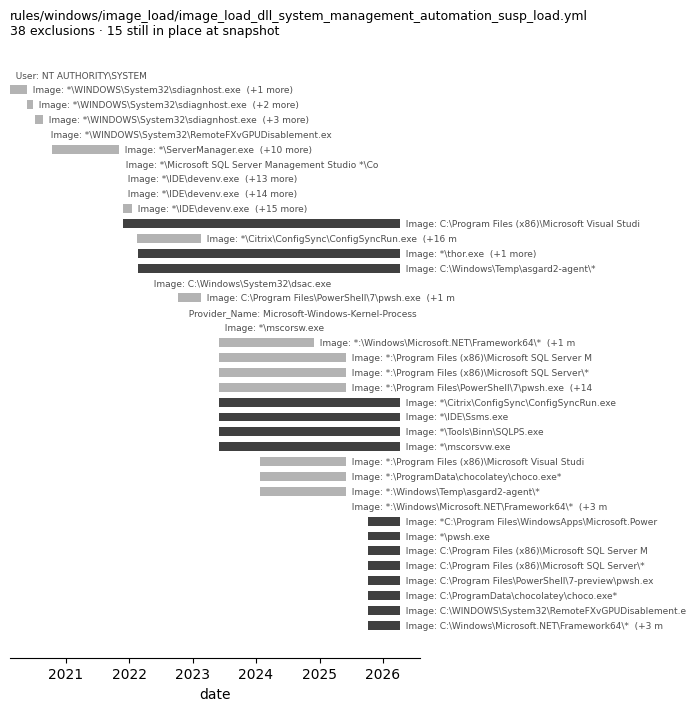

In [70]:
LID = 'lineage_03018'          # try 'lineage_00894' too

import matplotlib.pyplot as plt
from collections import defaultdict

steps = [s for s in res if s['lineage_id'] == LID]
vers = {}
for s in steps:
    for vi, sig in ((s['version_a'], s['sig_a']), (s['version_b'], s['sig_b'])):
        vers.setdefault(vi, (date_of.get((LID, vi)), neg_set(sig)))
order = [v for v in sorted(vers) if vers[v][0] is not None]

seen = defaultdict(list)
for v in order:
    for p in vers[v][1]:
        seen[p].append(v)

def label(p):
    f = p[2:].split('|')[0]
    vs = literals(p)
    t = norm(vs[0]) if vs else ''
    if len(vs) > 1:
        t += f'  (+{len(vs)-1} more)'
    return f'{f}: {t}'[:52]

rows = []
for p, vs in seen.items():
    a, b = min(vs), max(vs)
    rows.append((vers[a][0], vers[b][0], b == order[-1], label(p)))
rows.sort()

fig, ax = plt.subplots(figsize=(7, max(3, 0.19 * len(rows))))
for i, (t0, t1, live, lab) in enumerate(rows):
    end = SNAPSHOT if live else t1
    ax.barh(i, (end - t0).days, left=t0, height=0.6,
            color='0.25' if live else '0.7')
    ax.text(end, i, '  ' + lab, va='center', fontsize=6.5, color='0.3')

ax.set_yticks([]); ax.invert_yaxis()
ax.set_xlabel('date')
ax.set_title(f'{names.get(LID,LID)}\n{len(rows)} exclusions · '
             f'{sum(1 for r in rows if r[2])} still in place at snapshot',
             fontsize=9, loc='left')
for s in ('top','right','left'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

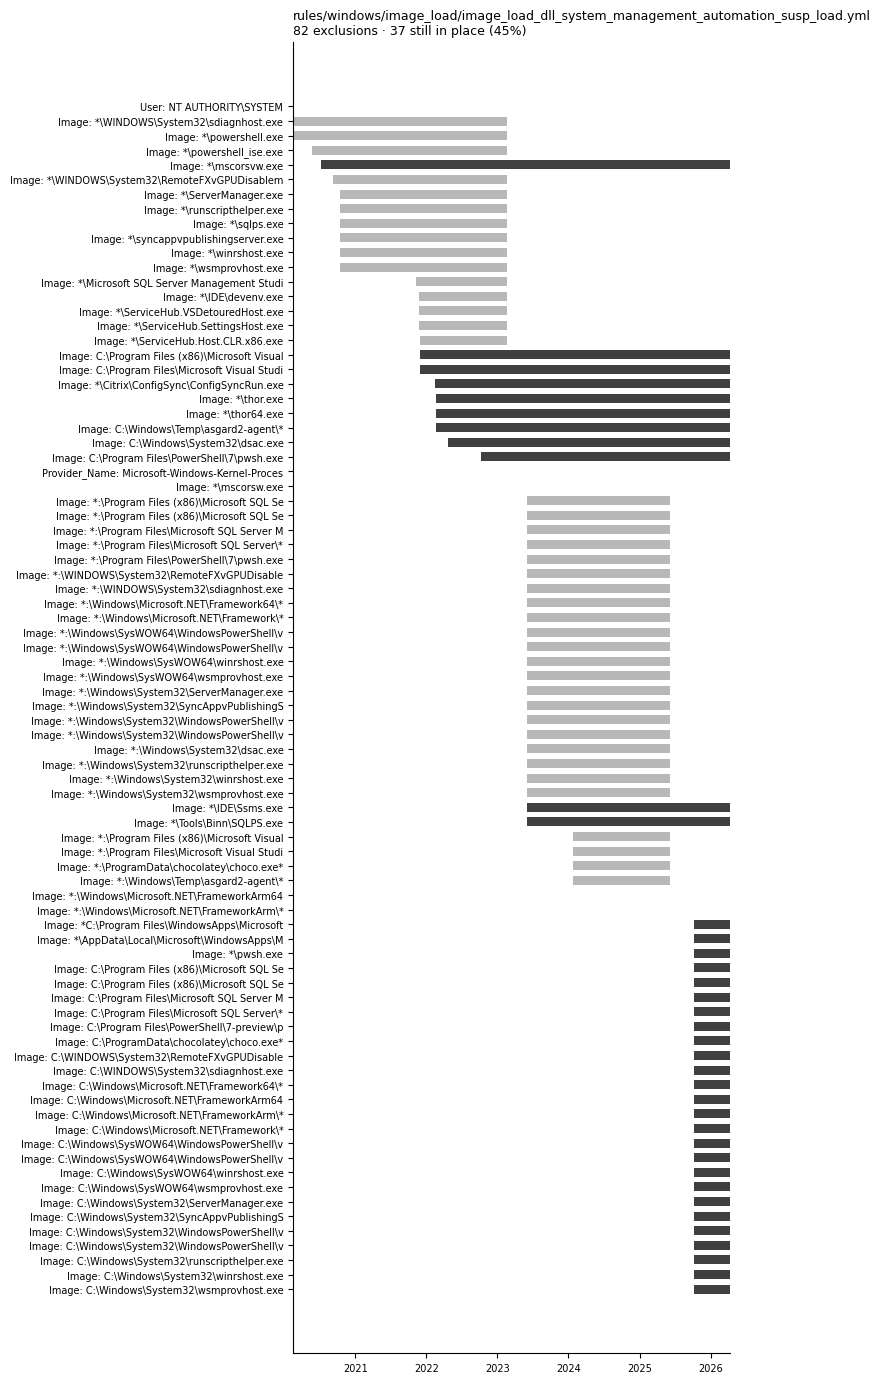

In [71]:
LID = 'lineage_03018'

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict

def neg_pairs(sig):
    return {(f, norm(v)) for f, p in neg_preds_fields(sig) for v in literals(p)}

steps = [s for s in res if s['lineage_id'] == LID]
vers = {}
for s in steps:
    for vi, sig in ((s['version_a'], s['sig_a']), (s['version_b'], s['sig_b'])):
        vers.setdefault(vi, (date_of.get((LID, vi)), neg_pairs(sig)))
order = [v for v in sorted(vers) if vers[v][0] is not None]

seen = defaultdict(list)
for v in order:
    for pair in vers[v][1]:
        seen[pair].append(v)

rows = []
for (f, val), vs in seen.items():
    a, b = min(vs), max(vs)
    rows.append((vers[a][0], vers[b][0], b == order[-1], f'{f}: {val}'[:46]))
rows.sort()
live = sum(1 for r in rows if r[2])

fig, ax = plt.subplots(figsize=(7.5, max(3, 0.17 * len(rows))))
for i, (t0, t1, alive, lab) in enumerate(rows):
    end = SNAPSHOT if alive else t1
    ax.barh(i, (end - t0).days, left=t0, height=0.62,
            color='0.25' if alive else '0.72')

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[3] for r in rows], fontsize=6)
ax.invert_yaxis()
ax.set_xlim(min(r[0] for r in rows), SNAPSHOT)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title(f'{names.get(LID, LID)}\n{len(rows)} exclusions · {live} still in place '
             f'({100*live/len(rows):.0f}%)', fontsize=9, loc='left')
ax.tick_params(labelsize=7)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [72]:
MIN_DAYS = 25
for i, (t0, t1, alive, lab) in enumerate(rows):
    end = SNAPSHOT if alive else t1
    w = max((end - t0).days, MIN_DAYS)
    ax.barh(i, w, left=t0, height=0.62, color='0.25' if alive else '0.72')

In [73]:
plt.savefig(str(RESULTS / 'fig_timeline.png'), dpi=600, bbox_inches='tight')
plt.savefig(str(RESULTS / 'fig_timeline.pdf'), bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [74]:
import re
subj = {}
for e in meta:
    for i, c in enumerate(e.get('commits', [])):
        subj[(e['lineage_id'], i)] = c.get('subject', '')

# does version_index really index into commits? check dates agree
import datetime
agree = tot = 0
for e in meta[:400]:
    for i, c in enumerate(e.get('commits', [])):
        d = date_of.get((e['lineage_id'], i))
        if d is None:
            continue
        tot += 1
        agree += str(c.get('date', ''))[:10] == str(d)[:10]
print(f'index alignment: {agree}/{tot} dates match ({100*agree/max(tot,1):.1f}%)')

index alignment: 738/3750 dates match (19.7%)


In [75]:
from collections import defaultdict
bydate = defaultdict(list)
for e in meta:
    for c in e.get('commits', []):
        bydate[(e['lineage_id'], str(c.get('date', ''))[:10])].append(c.get('subject', ''))

def subject_for(s):
    d = date_of.get((s['lineage_id'], s['version_b']))
    if d is None:
        return None, 'no date'
    ms = bydate.get((s['lineage_id'], str(d)[:10]), [])
    if len(ms) == 1: return ms[0], 'unique'
    if len(ms) > 1:  return ' | '.join(ms), 'ambiguous'
    return None, 'no commit'

from collections import Counter
res_j = [subject_for(s) for s in sup2]
print(Counter(k for _, k in res_j))

Counter({'unique': 1203, 'ambiguous': 439})


In [76]:
import re
FP = re.compile(r'\bfp\b|false[ -]?positive|noisy|noise|exclude|exclusion|filter|'
                r'tune|tuning|benign', re.I)

def rate(coll, label):
    uniq, amb = [], []
    for s in coll:
        m, kind = subject_for(s)
        if kind == 'unique':      uniq.append(m)
        elif kind == 'ambiguous': amb.append(m.split(' | '))
    u = sum(1 for m in uniq if FP.search(m))
    a_any = sum(1 for g in amb if any(FP.search(m) for m in g))
    a_all = sum(1 for g in amb if all(FP.search(m) for m in g))
    print(f'{label:<14} unique {u}/{len(uniq)} = {100*u/len(uniq):5.1f}%   '
          f'ambiguous {100*a_all/max(len(amb),1):.0f}–{100*a_any/max(len(amb),1):.0f}%  (n={len(amb)})')

rate(sup2, 'suppression')
rate(rel2, 'relaxation')
rate([s for s in res if not is_suppression(s) and not is_relaxation(s)], 'neither')

suppression    unique 461/1203 =  38.3%   ambiguous 9–56%  (n=439)
relaxation     unique 38/186 =  20.4%   ambiguous 11–51%  (n=118)
neither        unique 203/4528 =   4.5%   ambiguous 0–8%  (n=1760)


In [77]:
REASON = re.compile(r'\bfp\b|false[ -]?positive|noisy|noise|benign|'
                    r'legitimate|expected behaviou?r', re.I)
MECH   = re.compile(r'exclude|exclusion|filter|whitelist|allowlist', re.I)

def split_rate(coll, label):
    uniq = [m for s in coll for m, k in [subject_for(s)] if k == 'unique']
    r = sum(1 for m in uniq if REASON.search(m))
    x = sum(1 for m in uniq if MECH.search(m))
    print(f'{label:<14} n={len(uniq):>5}   reason {100*r/len(uniq):5.1f}%   '
          f'mechanism {100*x/len(uniq):5.1f}%')

split_rate(sup2, 'suppression')
split_rate(rel2, 'relaxation')
split_rate([s for s in res if not is_suppression(s) and not is_relaxation(s)], 'neither')

suppression    n= 1203   reason  30.9%   mechanism  10.8%
relaxation     n=  186   reason  15.6%   mechanism   5.4%
neither        n= 4528   reason   3.0%   mechanism   1.5%


In [78]:
ph = {e['lineage_id'] for e in meta
      if any('placeholder' in str(p).lower() for p in e.get('all_paths', []))}
n  = sum(1 for s in sup2 if s['lineage_id'] in ph)
nr = sum(1 for s in rel2 if s['lineage_id'] in ph)
print(f'placeholder lineages {len(ph)}   suppressions {n} ({100*n/len(sup2):.1f}%)   relaxations {nr}')
print(f'ratio excluding them: {(len(sup2)-n)/max(len(rel2)-nr,1):.1f} : 1   (headline 5.4 : 1)')

placeholder lineages 17   suppressions 2 (0.1%)   relaxations 0
ratio excluding them: 5.4 : 1   (headline 5.4 : 1)


In [79]:
import numpy as np
alld = list(date_of.values())
lids = {s['lineage_id'] for s in res}
per  = Counter(s['lineage_id'] for s in sup2)
v    = np.array([per.get(l, 0) for l in lids])
rpt  = np.array(list(cover.values()))

print(f'lineages                {len(lids):,}')
print(f'revision steps          {len(res):,}')
print(f'date range              {min(alld).date()} → {max(alld).date()}')
print(f'ATT&CK techniques       {len(cover):,}   singleton {(rpt==1).sum()}')
print(f'rules per technique     median {np.median(rpt):.0f}  max {rpt.max()}')
print(f'suppressions/lineage    mean {v.mean():.2f}  median {np.median(v):.0f}  max {v.max()}')
print(f'  lineages with none    {(v==0).sum():,} ({100*(v==0).mean():.0f}%)')
print(f'  lineages with 5+      {(v>=5).sum():,}')

lineages                2,355
revision steps          8,234
date range              2016-12-27 → 2026-04-01
ATT&CK techniques       329   singleton 84
rules per technique     median 3  max 173
suppressions/lineage    mean 0.70  median 0  max 32
  lineages with none    1,831 (78%)
  lineages with 5+      86


In [80]:
from collections import defaultdict
net = defaultdict(int)
for s in sup2: net[s['lineage_id']] += 1
for s in rel2: net[s['lineage_id']] -= 1

pos  = sum(1 for v in net.values() if v > 0)
zero = sum(1 for v in net.values() if v == 0)
neg  = sum(1 for v in net.values() if v < 0)
t = len(net)
print(f'lineages whose exclusion set was ever modified: {t}')
print(f'  ended net-narrower  {pos:>4}  ({100*pos/t:.1f}%)')
print(f'  ended net-unchanged {zero:>4}  ({100*zero/t:.1f}%)')
print(f'  ended net-wider     {neg:>4}  ({100*neg/t:.1f}%)')

import numpy as np
steps = Counter(s['lineage_id'] for s in res)
sv = np.array([steps[l] for l in {s['lineage_id'] for s in res}])
print(f'\nrevision steps per lineage: median {np.median(sv):.0f}  '
      f'mean {sv.mean():.1f}  with only 1: {(sv==1).sum()}')

lineages whose exclusion set was ever modified: 559
  ended net-narrower   481  (86.0%)
  ended net-unchanged   41  (7.3%)
  ended net-wider       37  (6.6%)

revision steps per lineage: median 2  mean 3.5  with only 1: 830


In [81]:
from forgeability import classify, is_path_field, base_field

In [82]:
import numpy as np
from collections import defaultdict

CMDLIKE = {'CommandLine','ParentCommandLine','SourceCommandLine','GrandparentCommandLine',
           'ScriptBlockText','_raw','Command','ParentCommand','Details','Message'}
REGLIKE = {'TargetObject','ObjectName','Data','ContextInfo'}

groups = defaultdict(list)
for s in sup2:
    a = neg_set(s['sig_a'])
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(field)[0] != 1 or is_path_field(field):
            continue
        g = 'command-line' if field in CMDLIKE else ('registry / data' if field in REGLIKE else 'other')
        for v in literals(pred):
            groups[g].append(norm(v).strip('*'))

for g, vs in sorted(groups.items(), key=lambda kv: -len(kv[1])):
    L = np.array([len(v) for v in vs])
    print(f'{g:<18} n={len(vs):>5}   length median {np.median(L):>3.0f}  '
          f'<15 chars {100*(L<15).mean():>4.0f}%   <8 chars {100*(L<8).mean():>3.0f}%')

print('\nshortest command-line exclusions (broadest, most easily matched):')
for v in sorted(set(groups['command-line']), key=len)[:20]:
    print(f'   {v!r}')

command-line       n=  954   length median  19  <15 chars   40%   <8 chars  20%
registry / data    n=  517   length median  47  <15 chars    6%   <8 chars   1%
other              n=  102   length median  20  <15 chars   36%   <8 chars  15%

shortest command-line exclusions (broadest, most easily matched):
   ''
   'l'
   '%'
   ' >'
   '02'
   ' \\'
   ' /'
   ' -c'
   'ADD'
   ' -z'
   '.ax'
   ' -f'
   'C:\\'
   '/i '
   ' -h'
   ' -t'
   ',#1'
   '.mof'
   ' ―c '
   '.exe'


In [83]:
from collections import Counter
short_ctx = []
for s in sup2:
    a = neg_set(s['sig_a'])
    added = [(f, p) for f, p in neg_preds_fields(s['sig_b']) if p not in a]
    for f, p in added:
        if f in CMDLIKE:
            for v in literals(p):
                if len(norm(v).strip('*')) < 8:
                    short_ctx.append((len(added), s['lineage_id'], norm(v)))

print(Counter(n for n, _, _ in short_ctx).most_common(8))
print(f'\nshort cmdline exclusions added ALONE: '
      f'{sum(1 for n,_,_ in short_ctx if n == 1)} of {len(short_ctx)}')
print('\nexamples added alone:')
for n, lid, v in [x for x in short_ctx if x[0] == 1][:12]:
    print(f'   {v!r:<20} {names.get(lid,"")[-45:]}')

[(1, 85), (15, 30), (2, 27), (3, 17), (4, 12), (16, 10), (5, 5), (6, 3)]

short cmdline exclusions added ALONE: 85 of 192

examples added alone:
   '*HKCU:\\*'          owershell_script/posh_ps_remove_item_path.yml
   '*HKLM:\\*'          owershell_script/posh_ps_remove_item_path.yml
   '*l*'                tion_lnx_susp_network_utilities_execution.yml
   '*l*'                tion_lnx_susp_network_utilities_execution.yml
   '* -l *'             tion_lnx_susp_network_utilities_execution.yml
   '*-s -*'             eation/proc_creation_macos_binary_padding.yml
   '*-s 0*'             eation/proc_creation_macos_binary_padding.yml
   '*cmd /c *'          /proc_creation_win_cmd_no_space_execution.yml
   '*cmd /k *'          /proc_creation_win_cmd_no_space_execution.yml
   '*cmd /c *'          /proc_creation_win_cmd_no_space_execution.yml
   '*cmd /k *'          /proc_creation_win_cmd_no_space_execution.yml
   '*cmd /r *'          /proc_creation_win_cmd_no_space_execution.yml


In [84]:
import json
for line in open(str(UPSTREAM / 'data_prep/build_data/rule_versions_sigma.jsonl'), encoding='utf-8'):
    r = json.loads(line)
    if 'network_utilities' in str(r.get('path_used', '')):
        print(r['commit_date'], r['path_used'])
        print(r['detection_block'][:1200])
        print('=' * 70)

2023-10-28T10:40:22Z rules/linux/process_creation/proc_creation_lnx_susp_network_utilities_execution.yml
selection_netcat:
    Image|endswith:
        - '/nc'
        - '/ncat'
        - '/netcat'
        - '/socat'
selection_network_scanning_tools:
    Image|endswith:
        - '/autorecon'
        - '/hping'
        - '/hping2'
        - '/hping3'
        - '/naabu'
        - '/nmap'
        - '/nping'
        - '/telnet' # could be wget, curl, ssh, many things. basically everything that is able to do network connection. consider fine tuning
filter_main_netcat_listen_flag:
    CommandLine|contains:
        - ' --listen '
        - ' -l '
condition: (selection_netcat and not filter_main_netcat_listen_flag) or selection_network_scanning_tools
2024-08-12T10:02:50Z rules/linux/process_creation/proc_creation_lnx_susp_network_utilities_execution.yml
selection_netcat:
    Image|endswith:
        - '/nc'
        - '/ncat'
        - '/netcat'
        - '/socat'
selection_network_scanning_tool

In [85]:
lids = [l for l, n in names.items() if 'network_utilities' in str(n)]
for s in res:
    if s['lineage_id'] in lids:
        for f, p in neg_preds_fields(s['sig_b']):
            if any(norm(v).strip('*') == 'l' for v in literals(p)):
                print(s['lineage_id'], f"v{s['version_a']}→v{s['version_b']}",
                      date_of.get((s['lineage_id'], s['version_b'])), f)

lineage_04120 v5→v6 2020-11-09 09:32:56+00:00 CommandLine
lineage_04120 v6→v7 2020-11-16 00:00:09+00:00 CommandLine
lineage_04120 v11→v12 2021-09-14 17:27:28+00:00 CommandLine


In [86]:
import json
print('rule:', names.get('lineage_04120'))
P = (str(UPSTREAM / 'data_prep/build_data/rule_versions_sigma.jsonl'))
for line in open(P, encoding='utf-8'):
    r = json.loads(line)
    if r['commit_date'][:10] in ('2020-11-09', '2020-11-16', '2021-09-14', '2021-09-15'):
        if 'network_util' in str(r.get('path_used', '')):
            print('\n===', r['commit_date'], r['path_used'])
            print(r['detection_block'][:900])

rule: rules/linux/process_creation/proc_creation_lnx_susp_network_utilities_execution.yml


In [87]:
import json, re
P = (str(UPSTREAM / 'data_prep/build_data/rule_versions_sigma.jsonl'))

hits = []
for line in open(P, encoding='utf-8'):
    r = json.loads(line)
    if 'network_utilities' in str(r.get('path_used', '')):
        blk = r.get('detection_block', '') or ''
        bare = bool(re.search(r"^\s*-\s*'l'\s*$", blk, re.M))
        hits.append((r['commit_date'][:10], bare, blk))
        print(r['commit_date'][:10], 'BARE-L' if bare else '')

print(f'\n{sum(1 for _, b, _ in hits if b)} of {len(hits)} versions carry a bare l')
b = next((h for h in hits if h[1]), None)
if b:
    print('\n===', b[0])
    print(b[2][:1000])

2023-10-28 
2024-08-12 
2024-09-22 

0 of 3 versions carry a bare l


In [88]:
paths4120 = [p for e in meta if e['lineage_id'] == 'lineage_04120'
             for p in e.get('all_paths', [])]
print(paths4120)

hits = []
for line in open(P, encoding='utf-8'):
    r = json.loads(line)
    if str(r.get('path_used', '')) in paths4120:
        blk = r.get('detection_block', '') or ''
        bare = bool(re.search(r"^\s*-\s*'l'\s*$", blk, re.M))
        hits.append((r['commit_date'][:10], bare, blk))
print(f"{len(hits)} versions, {sum(1 for _, b, _ in hits if b)} with bare l")
b = next((h for h in hits if h[1]), None)
if b:
    print('\n===', b[0]); print(b[2][:1000])

['rules/linux/process_creation/proc_creation_lnx_susp_network_utilities_execution.yml', 'rules/linux/lnx_network_service_scanning.yml', 'rules/linux/process_creation/lnx_network_service_scanning.yml', 'rules/linux/process_creation/proc_creation_lnx_network_service_scanning.yml']
20 versions, 0 with bare l


In [89]:
from collections import defaultdict
path2lid = {p: e['lineage_id'] for e in meta for p in e.get('all_paths', [])}
blocks = defaultdict(str)
for line in open(P, encoding='utf-8'):
    r = json.loads(line)
    lid = path2lid.get(str(r.get('path_used', '')))
    if lid:
        blocks[lid] += (r.get('detection_block', '') or '')

real = art = 0
examples = []
for s in sup2:
    a = neg_set(s['sig_a'])
    for field, pred in neg_preds_fields(s['sig_b']):
        if pred in a or field not in CMDLIKE:
            continue
        for v in literals(pred):
            t = norm(v).strip('*')
            if 0 < len(t) < 8:
                if t in blocks.get(s['lineage_id'], ''):
                    real += 1
                else:
                    art += 1
                    if len(examples) < 12:
                        examples.append((t, names.get(s['lineage_id'], '')[-40:]))

print(f'short cmdline literals — found in raw YAML: {real}   not found: {art}  '
      f'({100*art/max(real+art,1):.0f}% suspect)')
for t, n in examples:
    print(f'   {t!r:<16} {n}')

short cmdline literals — found in raw YAML: 167   not found: 18  (10% suspect)
   ' –a '           roc_creation_win_regedit_import_keys.yml
   ' –c '           roc_creation_win_regedit_import_keys.yml
   ' –e '           roc_creation_win_regedit_import_keys.yml
   ' —a '           roc_creation_win_regedit_import_keys.yml
   ' —c '           roc_creation_win_regedit_import_keys.yml
   ' —e '           roc_creation_win_regedit_import_keys.yml
   ' ―a '           roc_creation_win_regedit_import_keys.yml
   ' ―c '           roc_creation_win_regedit_import_keys.yml
   ' ―e '           roc_creation_win_regedit_import_keys.yml
   ' –a '           creation_win_regedit_import_keys_ads.yml
   ' –c '           creation_win_regedit_import_keys_ads.yml
   ' –e '           creation_win_regedit_import_keys_ads.yml


In [90]:
import re
def breadth(v):
    v = norm(v).strip()
    if not v: return 'empty'
    if re.search(r'[\\/]\*+$', v): return 'directory tree'
    if v.count('*') >= 2:          return 'multi-wildcard pattern'
    if re.search(r'\.[a-z0-9]{2,4}\*?$', v, re.I): return 'specific file'
    return 'other'

cross = Counter()
for s in sup2:
    a = neg_set(s['sig_a'])
    for f, pred in neg_preds_fields(s['sig_b']):
        if pred in a or classify(f)[0] != 1 or not is_path_field(f): continue
        for v in literals(pred):
            cross[(anchor(v), breadth(v))] += 1

tot = sum(cross.values())
for k, n in cross.most_common():
    print(f'{k[0]:<22} {k[1]:<24} {n:>5}  {100*n/tot:5.1f}%')

bare name or suffix    specific file             2609   48.9%
protected path         specific file              984   18.4%
protected path         directory tree             685   12.8%
bare name or suffix    directory tree             234    4.4%
bare name or suffix    multi-wildcard pattern     197    3.7%
user-writable path     directory tree             181    3.4%
other absolute path    directory tree              86    1.6%
user-writable path     specific file               85    1.6%
protected path         other                       67    1.3%
bare name or suffix    other                       65    1.2%
user-writable path     multi-wildcard pattern      45    0.8%
other absolute path    specific file               28    0.5%
protected path         multi-wildcard pattern      23    0.4%
empty                  empty                       21    0.4%
other absolute path    other                       14    0.3%
user-writable path     other                        5    0.1%
other re